#**OBJECTIVE**

**The purpose of the analysis is to identify and evaluate the key factors driving first-day viewership of content on ShowTime, an OTT service provider.  This study will employ a linear regression model to analyse the impact of variables such as user platform engagement, advertising strategies, content scheduling, and external factors such as weekends and vacations.  The model's findings will help ShowTime design focused strategies to boost content visibility and overall platform engagement, resulting in higher first-day viewership.**

#**KEY QUESTIONS**

* **What does the distribution of content views look like?**
* **What does the distribution of genres look like?**
* **The day of the week on which content is released generally plays a key role in the viewership. How does the viewership vary with the day of release?**
* **How does the viewership vary with the season of release?**
* **What is the correlation between trailer views and content views?**

#**DATA DESCRIPTION**

The dataset covers the various distinct factors for content analysis.  The detailed data dictionary is provided below.

**Data Dictionary:**

1. **visitors:** Average number of visitors, in millions, to the platform in the past week
2. **ad_impressions:** Number of ad impressions, in millions, across all ad campaigns for the content (running and completed)
3. **major_sports_event:** Any major sports event on the day
4. **genre:** Genre of the content
5. **dayofweek**: Day of the release of the content
6. **season:** Season of the release of the content
7. **views_trailer:** Number of views, in millions, of the content trailer
8. **views_content:** Number of first-day views, in millions, of the content

#**IMPORTING LIBRARIES**

In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

#to suppress warnings
import warnings
warnings.filterwarnings('ignore')

# split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model using statsmodels
import statsmodels.api as sm

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# to compute VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor





#**DATA OVERVIEW**

The objective of this step is to get an overview of our dataset by:

* observing the first few rows of the dataset, to check whether the dataset has been loaded properly or not.
* fetching information regarding the number of rows and columns in the dataset.
* finding out the data types of the columns to ensure that data is stored in the preferred format and the value of each property is as expected.
*  checking the statistical summary of the dataset to get an overview of the numerical columns of the dataset.

Upload the dataset.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ottdata.csv to ottdata.csv


Load the dataset

In [ ]:
data = pd.read_csv('ottdata.csv')

Display Top 5 Rows

In [ ]:
data.head()

,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
0,1.67,1113.81,0,Horror,Wednesday,Spring,56.70,0.51
1,1.46,1498.41,1,Thriller,Friday,Fall,52.69,0.32
2,1.47,1079.19,1,Thriller,Wednesday,Fall,48.74,0.39
3,1.85,1342.77,1,Sci-Fi,Friday,Fall,49.81,0.44
4,1.46,1498.41,0,Sci-Fi,Sunday,Winter,55.83,0.46


Display Bottom 5 Rows

In [ ]:
data.tail()

,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
995,1.58,1311.96,0,Romance,Friday,Fall,48.58,0.36
996,1.34,1329.48,0,Action,Friday,Summer,72.42,0.56
997,1.62,1359.80,1,Sci-Fi,Wednesday,Fall,150.44,0.66
998,2.06,1698.35,0,Romance,Monday,Summer,48.72,0.47
999,1.36,1140.23,0,Comedy,Saturday,Summer,52.94,0.49


Checking shape of dataset.


In [ ]:
data.shape

(1000, 8)

------------------------------------------------------------------------------
**Observations:**

* We can observe that shape of dataset shows there are 1000 rows and 8 columns.

------------------------------------------------------------------------------

Checking Data Types.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visitors            1000 non-null   float64
 1   ad_impressions      1000 non-null   float64
 2   major_sports_event  1000 non-null   int64  
 3   genre               1000 non-null   object 
 4   dayofweek           1000 non-null   object 
 5   season              1000 non-null   object 
 6   views_trailer       1000 non-null   float64
 7   views_content       1000 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 62.6+ KB


-----------------------------------------------------------------------------
**Observations:**

* ***Data types:*** 5 numerical columns and 3 categorical columns ( genre, dayofweek,season).

------------------------------------------------------------------------------

Checking Statistical Summary

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
visitors,1000.0,1.70429,0.231973,1.25,1.5500,1.70,1.830,2.34
ad_impressions,1000.0,1434.71229,289.534834,1010.87,1210.3300,1383.58,1623.670,2424.20
major_sports_event,1000.0,0.40000,0.490143,0.00,0.0000,0.00,1.000,1.00
views_trailer,1000.0,66.91559,35.001080,30.08,50.9475,53.96,57.755,199.92
views_content,1000.0,0.47340,0.105914,0.22,0.4000,0.45,0.520,0.89


------------------------------------------------------------------------------
**Statistical Summary Observations:**

**1. Visitors**

*Stats:*  

Mean = 1.70M, Median = 1.70M, Standard Deviation = 0.23M, Min = 1.25M, Max = 2.34M, IQR = 1.55M - 1.33M

*Interpretation:*

The data shows mean ≈ median (symmetric distribution) but has a low variance (SD = 0.23M) implies stable daily visitor volume. This tight IQR (a range of 0.28M) also verifies 50% of days had visitors between  1.55M - 1.33M, with rare extremes beyond this range.


**2. ad_impressions**

*Statistics:*

Mean = 1434.7, Median = 1383.6, Standard Deviation = 289.5, Min = 1010.9, Max = 2424.2, IQR = 1210.3 - 1623.7

*Interpretation:*

Data shows right-skewed distribution (mean > median) and high variability (SD = 289.5) suggest frequent fluctuations. The wide IQR (413.4 range) and max value (2,424.2, 49% above median) indicate occasional high-impact days, likely driven by external factors like vacations or events.

**3. major_sports_event**

*Statistics:*

Binary data (0/1) represents yes or no, Mean = 0.4, standard deviation = 0.49, Frequency = 40% (400 days).

*Interpretation:*

The dataset was dominated by non-event days (60%) with events occurring on 40% of days. In other metrics (such ad_impressions), this imbalance might aid in the analysis of event-driven traffic spikes.


**4. Views Trailer**

*Statistics:*

Mean = 66.91, Median = 53.96, Standard Deviation = 35.0, Min = 30.08, Max = 199.92, IQR = 50.94-57.75

*Interpretation:*

High standard deviation and extreme right-skew (mean >> median) indicate irregular views on trailer.  Although 75% of days had ≤57.8 views, unusual outliers (max = 199.9, 246% above median) could indicate viral traction or marketing abnormalities.

**5. Views Content**

*Statistics:*

Mean = 0.47, Median = 0.45, Standard Deviation = 0.11, Min = 0.22, Max = 0.89, IQR = 0.40-0.52

*Interpretation:*

Near-symmetric distribution (mean ≈ median) and low std dev denote consistent user engagement. The compact IQR (0.12 range) shows 50% of days had content views between 0.40-0.52, with no extreme outliers.

------------------------------------------------------------------------------

Checking unique values and  counts for categorical data

In [ ]:
unique_counts = data.nunique()
print("Unique values are:")
unique_counts

Unique values are:


,0
visitors,56
ad_impressions,80
major_sports_event,2
genre,8
dayofweek,7
season,4
views_trailer,799
views_content,61


In [ ]:
# Select columns with 'object' data type
cat_cols = data.select_dtypes(include='object').columns

print("Categorical columns:")
print(cat_cols)

print("\nValue counts for each categorical column:")
print(data[cat_cols].nunique())

print("\n", data['dayofweek'].value_counts())
print("\n", data['season'].value_counts())
print("\n", data['genre'].value_counts())

Categorical columns:
Index(['genre', 'dayofweek', 'season'], dtype='object')

Value counts for each categorical column:
genre        8
dayofweek    7
season       4
dtype: int64

 dayofweek
Friday       369
Wednesday    332
Thursday      97
Saturday      88
Sunday        67
Monday        24
Tuesday       23
Name: count, dtype: int64

 season
Winter    257
Fall      252
Spring    247
Summer    244
Name: count, dtype: int64

 genre
Others      255
Comedy      114
Thriller    113
Drama       109
Romance     105
Sci-Fi      102
Horror      101
Action      101
Name: count, dtype: int64


------------------------------------------------------------------------------

**Observations on content release counts based on attributes categories:**

***1. Dayofweek***

*Observations:*
* Releases on Friday (36.9%) and Wednesday (33.2%) account for 70.1% of total material.
* Releases on Mondays (2.4%) and Tuesdays (2.3%) are infrequent.
* The weekend (Saturday: 8.8%, Sunday: 6.7%) and midweek (Thursday: 9.7%) are secondary options.

*Inferences:*
* In order to reach as many people as possible, publishers should strategically time their releases to coincide with midweek (Wednesday) and weekend transitions (Friday).

* Avoiding early-week releases: Monday and Tuesday appear to be low-engagement days, as evidenced by the few releases on these days.

* Bias alert: Wed/Fri patterns will be over-represented in the "release day impact" analysis.


***2. season***

*Observations:*

* Winter (25.7%), Fall (25.2%), Spring (24.7%), and Summer (24.4%) are in almost perfect balance.

* The maximum and minimum differences between winter and summer are 1.3%.

*Inferences:*
*  Seasons have equal distributions of content, suggesting so seasonal preferences.

***3. genre***

*Observations:*

* "Others" is the most common (25.5%): This genre category is 2.2 times larger than normal.

* There is balance among other genres:

* Drama (10.9%), Thriller (11.3%), and Comedy (11.4%)

* Horror (10.1%), Action (10.1%), Sci-Fi (10.2%), and Romance (10.5%).

* The genre range (excluding "Others") is 10.1-11.4% (a difference of 1.3%).

*Inference:*
* The content release is evenly distributed across major genres, but 1 in 4 releases is uncategorized ("Others").

------------------------------------------------------------------------------

Checking for Duplicates

In [ ]:
print("Number of duplicate:")
data.duplicated().sum()

Number of duplicate:


np.int64(0)

------------------------------------------------------------------------------
**Observation:**

* There are no duplicates in our dataset.

------------------------------------------------------------------------------


Checking missing values

In [ ]:
print("Missing values:")
data.isnull().sum()

Missing values:


,0
visitors,0
ad_impressions,0
major_sports_event,0
genre,0
dayofweek,0
season,0
views_trailer,0
views_content,0


------------------------------------------------------------------------------
**Observations:**

* There are no missing values in our dataset.

------------------------------------------------------------------------------


In [ ]:
# creating a copy of the data so that original data remains unchanged.
df = data.copy()

#**EXPLORATORY DATA ANALYSIS & ANSWERING KEY QUESTIONS**

##**Univariate Analysis**

* We will define functions below to carry out EDA.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def custplot_box_hist(
    df_copy,
    column_name,
    figure_size=(10,6),
    show_kde=False,
    num_bins=20,
    box_color=None,
    hist_color=None
):
    """
    Combined boxplot + histogram for a numeric column.

    Parameters
    ----------
    df_copy : pandas.DataFrame
        DataFrame to plot.
    column_name : str
        Column to visualise.
    figure_size : tuple, optional
        Overall figure size (default (10, 6)).
    show_kde : bool
        Overlay a KDE curve on the histogram.
    num_bins : int, optional
        Number of histogram bins (default 20).
    box_color : str or None
        Colour for the boxplot (name like 'violet', 'skyblue', etc).
    hist_color : str or None
        Colour for the histogram (name or palette color).
    """

    fig, (box_ax, hist_ax) = plt.subplots(
        nrows=2,
        sharex=True,
        figsize=figure_size,
        gridspec_kw={"height_ratios": [1, 3]}
    )

    # ── Boxplot ──
    sns.boxplot(
        x=df_copy[column_name],
        ax=box_ax,
        showmeans=True,
        color=box_color,
        meanprops={"marker": "o", "markerfacecolor": "gold"}
    )
    box_ax.set(title=f"Boxplot and Histogram of {column_name}", xlabel="")

    # ── Histogram ──
    sns.histplot(
        df_copy[column_name],
        ax=hist_ax,
        bins=num_bins,
        kde=show_kde,
        color=hist_color
    )

    # Mean and Median lines
    hist_ax.axvline(df_copy[column_name].mean(),   color="red", linestyle="--", label="Mean")
    hist_ax.axvline(df_copy[column_name].median(), color="black", linestyle="-",  label="Median")
    hist_ax.legend()

    plt.tight_layout()
    plt.show()
    plt.close(fig)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def cust_label_barplot(
    df_copy,
    column_name,
    figure_size=(10, 6),
    show_percent=False,
    top_n=None,
    palette=None        # for any matplotlib/seaborn colour or palette
):
    """
    Barplot of a categorical feature with count/percentage labels.

    Parameters
    ----------
    df_copy : pandas.DataFrame
        DataFrame to plot.
    column_name : str
        Categorical column to visualise.
    figure_size : tuple, optional
        Figure size in inches (default (10, 6)).
    show_percent : bool, optional
        If True, show percentages; else show counts.
    top_n : int or None, optional
        Limit to the top‑N most frequent categories.
    palette : str, list, dict or None, optional
        Colour palette (e.g. "Set2", ["skyblue","orange"], {"A":"teal",…}).
        If None, Seaborn’s default colour cycle is used.
    """

    # order the categories by frequency, optionally truncate to top_n
    category_order = df_copy[column_name].value_counts().index[:top_n]
    bar_count      = len(category_order)

    # set up the fig size with dynamic width
    plt.figure(figsize=(max(bar_count + 2, figure_size[0]), figure_size[1]))

    # draw the bars
    ax = sns.countplot(
        data=df_copy,
        x=column_name,
        order=category_order,
        palette=palette,
    )

    # tidy x‑axis labels
    plt.xticks(rotation=45, fontsize=10)
    if ax.get_legend() is not None:
        ax.legend_.remove()     # each bar is self‑explanatory

    # annotate bars
    total = len(df_copy[column_name])
    for bar in ax.patches:
        height = bar.get_height()
        label  = f"{(height / total) * 100:.1f}%" if show_percent else f"{height}"
        x      = bar.get_x() + bar.get_width() / 2
        ax.annotate(
            label, (x, height),
            ha="center", va="bottom",
            fontsize=12,
            xytext=(0, 5), textcoords="offset points"
        )

    plt.tight_layout()
    plt.show()

    plt.close(ax.figure)        # prevents duplicate plots



* Univariate analysis on all columns.

**visitors distribution.**

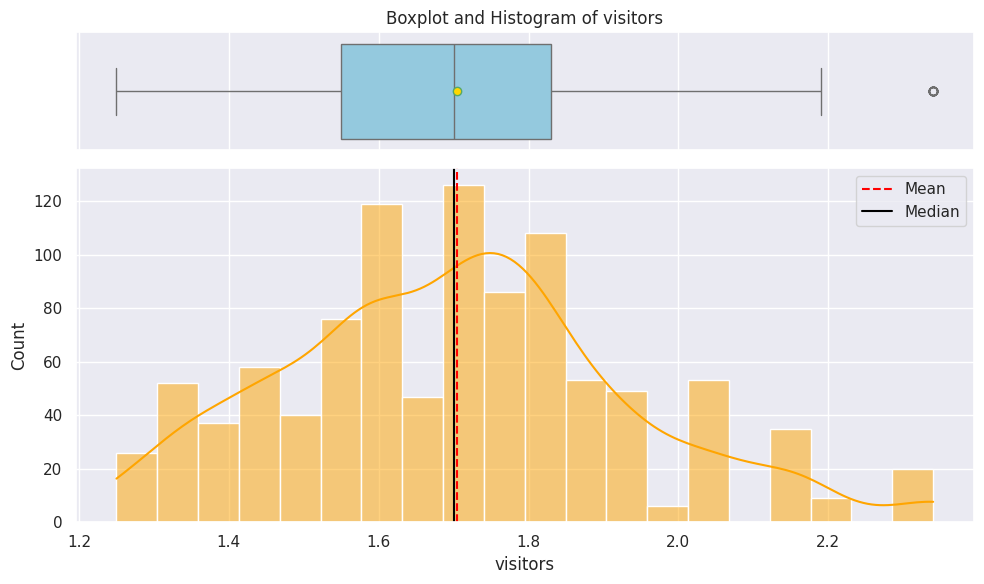

In [ ]:
custplot_box_hist(df, "visitors", show_kde=True, box_color="skyblue", hist_color="orange")

**Observations:**

*Histogram plot:*
* The histogram depicts the distribution of visitors ranging from 1.2 to 2.2 million.
* The distribution appears to be slightly right-skewed, with a greater concentration of values between 1.5 and 1.8 million visitors.
*The majority of visitors range from 1.6 to 1.8 million, with a peak of about 1.7 million.
* There are fewer examples of content with either low or extremely high visitor counts (less than 1.3 million or more than 2.0 million).

*Boxplot:*
* The boxplot verifies that the distribution of visitor counts is slightly right skewed, as indicated by the histogram. The median is slightly to the left of the box, indicating the presence of a tail on the right, or upper end of the distribution.
* Median: The median visitor count seems to be approximately 1.7 million.
* Mean (gold dot) is equal to median.
* Outliers: There appears to be some outliers present on the higher end (beyond upper whiskers) of the visitor counts. This implies that there may be a few content releases that received much more visitors than the average content.





**ad_impressions distribution.**

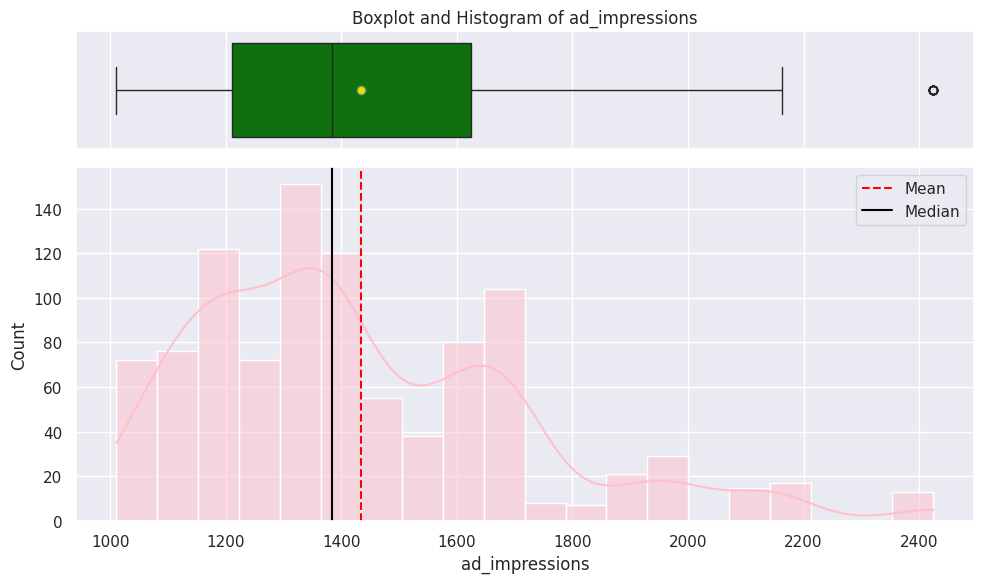

In [ ]:
custplot_box_hist(df, "ad_impressions", show_kde=True, box_color="green", hist_color="pink")

**Observations**

*Histogram:*
* The Plot depicts data is right-skewed, with the majority of values ranging between 1000 and 1500. Peaks around 1200, 1400 and 1600.
* The long tail stretches right till 2400, indicating fewer high-impression campaigns.

*Boxplot:*
* Distribution is right skewed with median around 1400. Mean ( gold dot on boxplot) > median.
* There is an outlier present beyond 2400, above upper whiskers, suggesting higher ad impression for certain campaigns.


**Distribution of major_sports_event.**

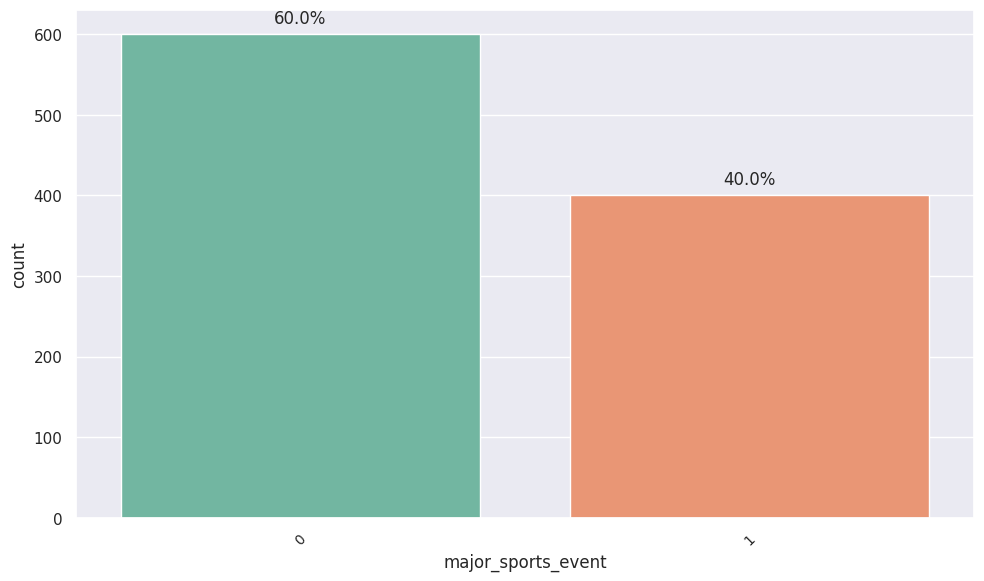

In [ ]:
cust_label_barplot(df, "major_sports_event", palette="Set2", show_percent=True)

**Observations**

* The bar plot shows there would be 60% content release on normal day, while 40% of releases will be on major sports event.
* **Note:** major_sports_event day: 1 = Yes, 0 =No.


**Distribution of dayofweek**

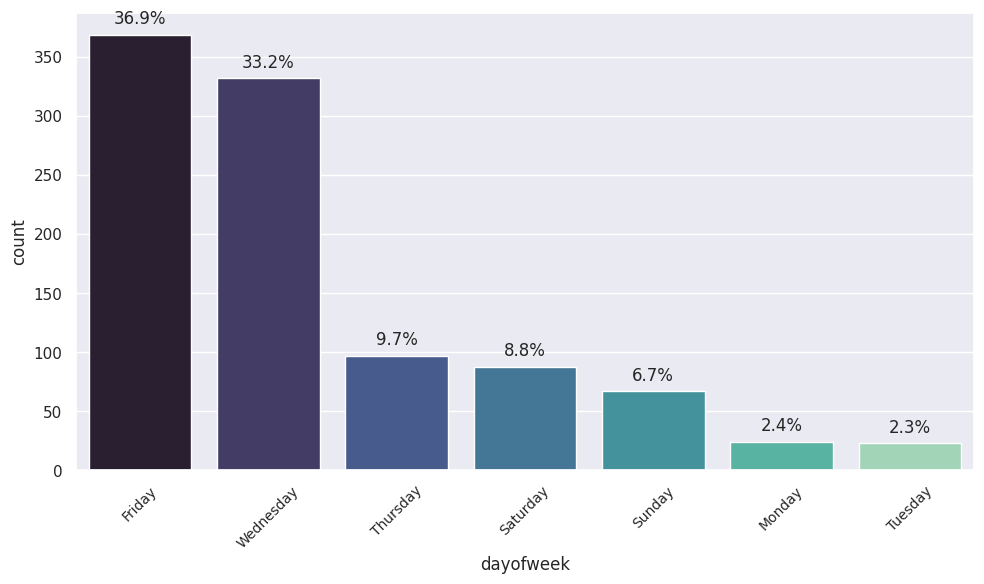

In [ ]:
cust_label_barplot(df, "dayofweek", palette="mako", show_percent=True)

**Observations**

* Day of the Week is a nominal categorical variable having a bimodal, unbalanced distribution.
* The majority of content is released on Fridays (37%), followed by Wednesdays (33%), with Mondays and Tuesdays being the least used, showing that Friday and Wednesday are prime viewing days.

**Distribution of seasons**

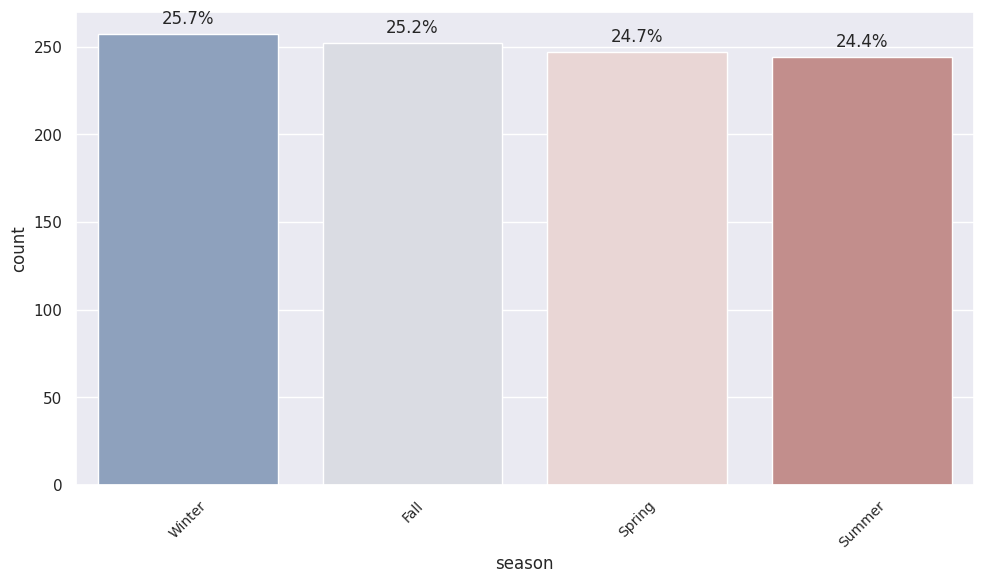

In [ ]:
cust_label_barplot(df, "season", palette="vlag", show_percent=True)

**Observations**

* Winter (25.7%), Fall (25.2%), Spring (24.7%), and Summer (24.4%) releases were essentially flat, indicating that the factor is well balanced for modelling.
* Plot shows nearly uniform distribution.
* High content release during winter and summer seasons.  
* Autumn and spring are the seasons with the least content release.  
* This could be due to a seasonal shift in the viewer's content preferences.



**Distribution of view_trailer.**

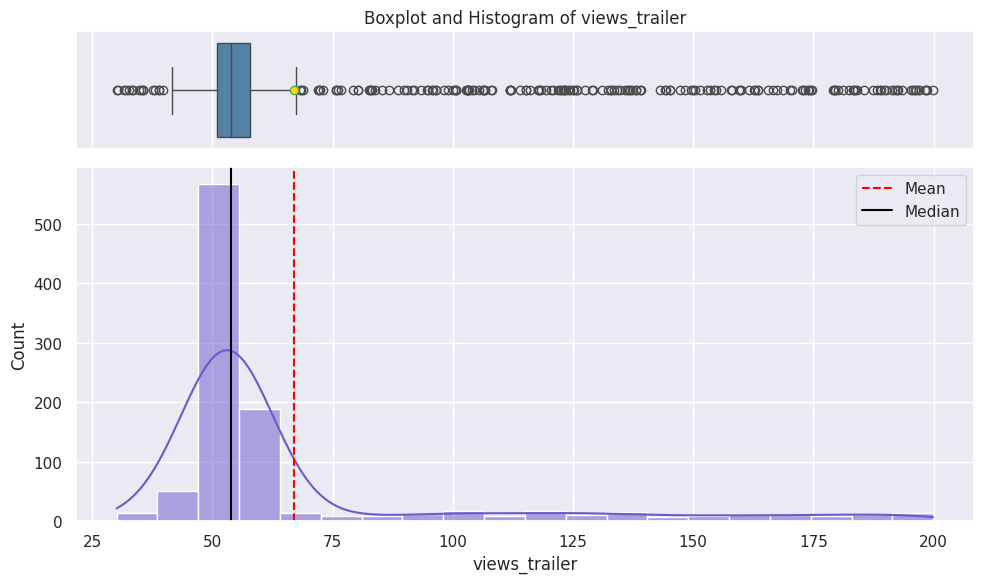

In [ ]:
custplot_box_hist(df, "views_trailer", show_kde=True, box_color="steelblue", hist_color="slateblue")

**Observations**

*Histogram:*
* The distribution of trailer views is highly right-skewed, with the majority of the data concentrated between 50 million and 75 million views, indicating that most content receives less trailer views, while a handful receive much more.
* The median trailer views are approximately 53.96 million, with a mean of 66.91 million.

*Boxplot:*

* The boxplot reveals a considerable number of outliers that exceed 75 million views, with a maximum value of 199.92 million.
* These outliers have much greater trailer views, possibly due to popularity or extensive marketing efforts.
* Analysing the relationship between trailer views and first-day content views can reveal whether good trailer promotion influences overall viewership.


**Distribution of views_content.**

##**Q1. What does the distribution of content views look like?**

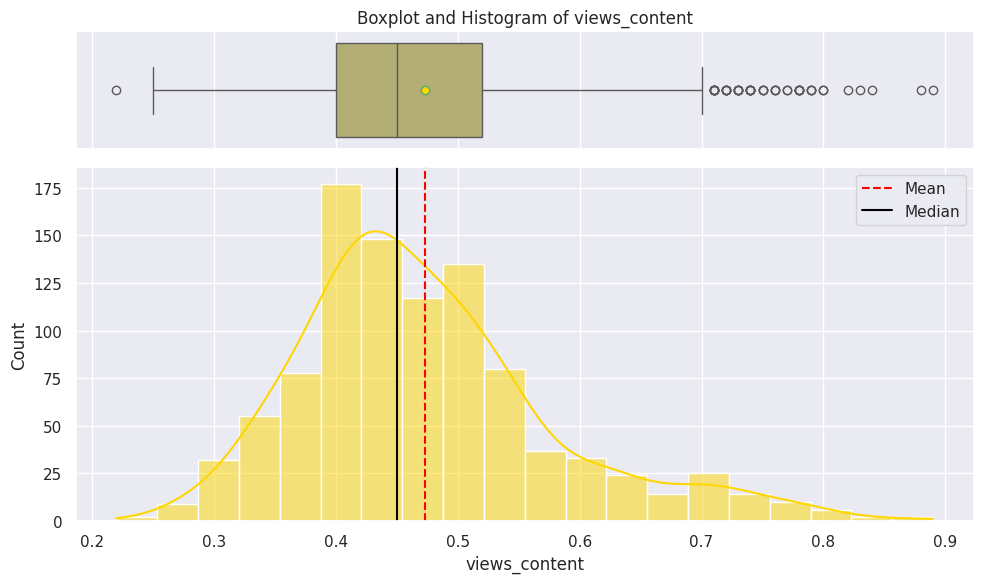

In [ ]:
custplot_box_hist(df, "views_content", show_kde=True, box_color="darkkhaki", hist_color="gold")

**Observations**

*Histogram:*
* The distribution of first day content view has moderate right-skewness and approximately normal, with majority of content views is concentrated between 0.4M to 0.5M.
* First-day content views with Mean = 0.47 and Median = 0.45M.

*Boxplot:*
* The boxplot reveals several outliers on the beyond upper whiskers with 0.7-0.9 millions view on first-day of content release and one outlier outside the lower whiskers with approximately 0.2 million views on first-day of content release, potentially due to popularity, strong marketing, or other factors.

* Overall, the content views data is relatively normally distributed with a slight right skew, indicating a typical range of content views values around the mean.
* Analysing the relationship between trailer views and first-day content views can reveal whether good trailer promotion influences overall viewership.
------------------------------------------------

**Distribution of genre.**

##**Q2. What does the distribution of genres look like?**

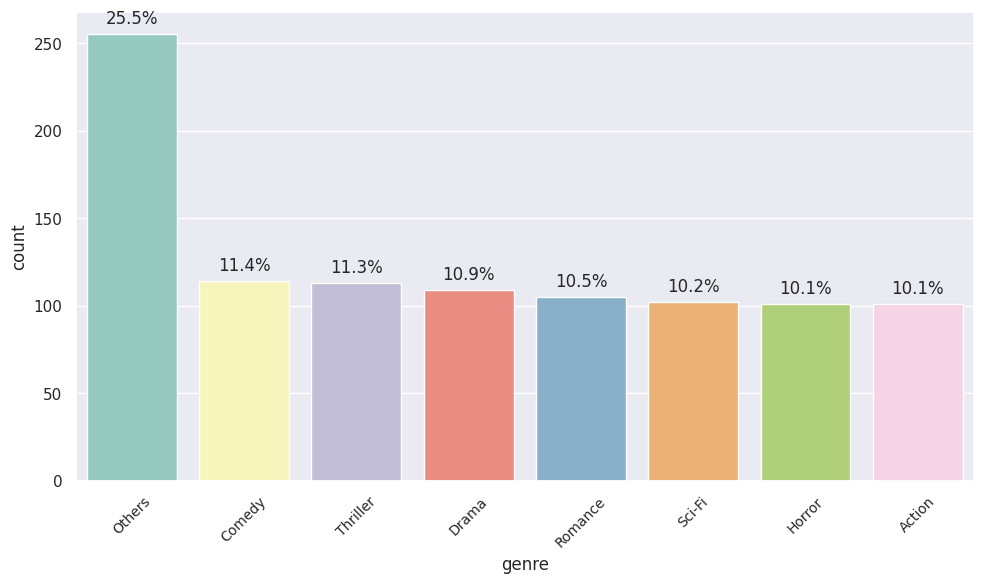

In [ ]:
cust_label_barplot(df, "genre", palette="Set3", show_percent=True)

**Observations**

* The bar chart represents a long-tail catalogue with unbalanced distribution.
* "Others" genre takes the lead with 26% of content release in this category, followed by Comedy (11.4%), Thriller (11.3%),Drama (10.9%) and Romance (10.5%).
* Others genre might represent significant content that doesn't fit traditional genres.
* The amount of content releases in the action, horror, and science fiction genres is relatively low (10.1-10.2%).
* Understanding the popularity of various genres might be useful in content strategy.

##**Bivariate Analysis**

Checking correaltion between Numerical vs. Numerical columns.

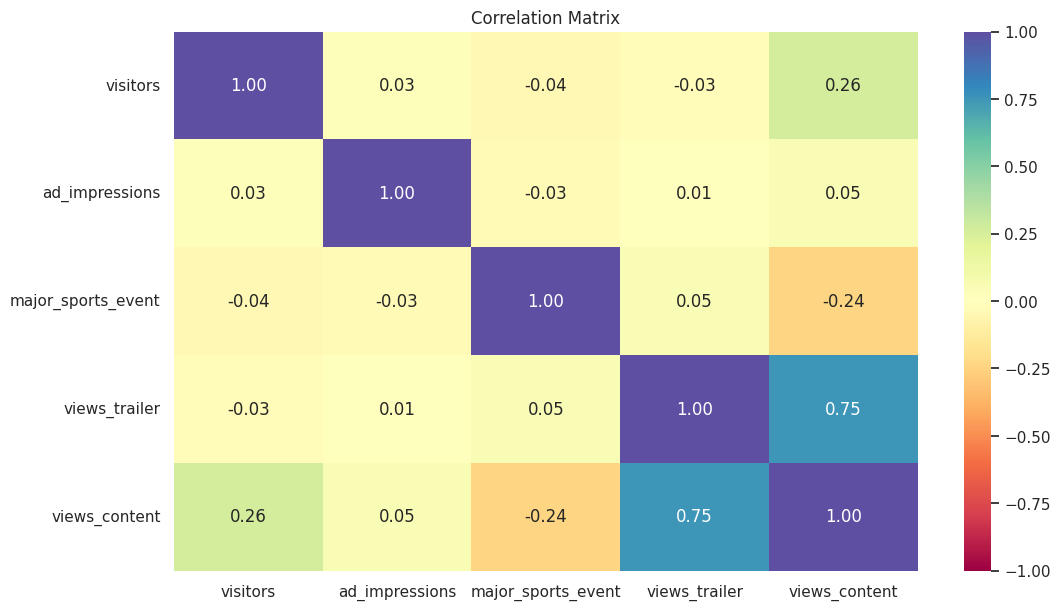

In [ ]:
num_cols = ['visitors','ad_impressions','major_sports_event','views_trailer','views_content']
plt.figure(figsize=(12, 7))
sns.heatmap(df[num_cols].corr(), annot=True,vmin=-1, vmax=1,fmt=".2f", cmap='Spectral')
plt.title('Correlation Matrix')
plt.show()

**Observations**

*views_trailer vs. views_content:*
* views_trailer and views_content (target variable) show a strong positive linear correlation (r = +0.75), indicating that more views on trailer of the content result in more first-day views of the content.
* This means that as the number of trailer views increases, so do first-day content views. This shows that trailer popularity is the most important numeric predictor of content performance on Day One.

*views_content vs. visitors:*
* Views_content and visitors have weak positive correlation (r = +0.26).
* When platform traffic rises overall due to increases number of visitors, there is a minor trend for content to get more views.
* While the association is not particularly strong and significant, increased platform activity has a beneficial impact on day-one viewership.


*ad_impressions vs. views_content:*
* ad_impressions and views_content have a very weak positive correlation (r = +0.05).
* The number of ad impressions seems to have almost no linear relationship with first-day views.
* This shows that simply displaying ads is insufficient; their efficacy may be more dependent on content quality, targeting, or conversion to trailer views than mere volume.

*major_sports_event vs. views_content:*
* The chance of major sports event on the day of content release and the views on content has moderate negative correlation (r = -0.24).
* Launching content during a major sporting event results in significantly reduced day-one viewership.
* Content planners should avoid large match nights for flagship releases

*major_sports_event vs. visitors, ad_impressions, views_trailer:*
* major sport even on the day of release has very weak negative correlation with visitors (r = -0.04) and ad_impressions (r = -0.03), suggesting less traffic due to major sports event, and campaigns might tends to run marginally fewer impressions on sports day.
* major sport even on the day of release has very weak positive correlation with views_trailer (r = +0.05), indicates that trailers are still watched on sports events day but get less views than non-sports event days.



**Inferences**
* Target marketing to increase views_trailer, as trailer engagement is the primary numerical variable.
* Sports events degrade performance; avoid them for major content releases.
* There is no risk of multicollinearity since, with the exception of the deliberate 0.75 link to the target, all predictor-to-predictor correlations are close to zero, allowing all numerical features to remain safely in the regression model.

**visitors vs. views_content**

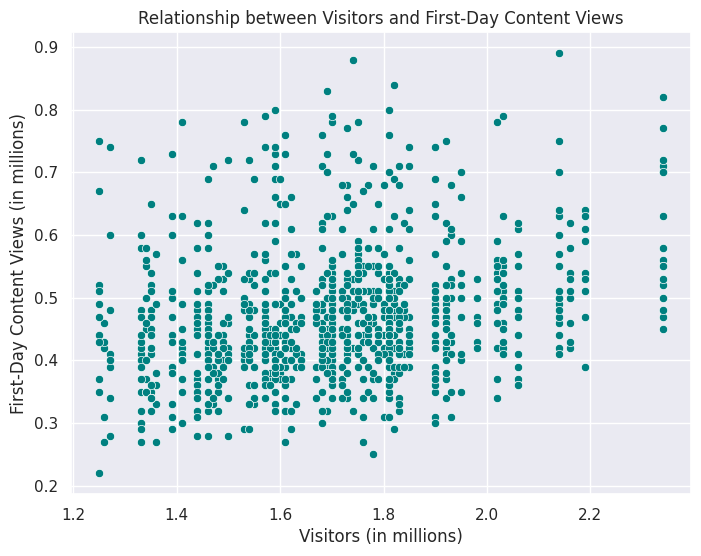

In [ ]:
# Scatter plot to visualize the relationship
plt.figure(figsize=(8, 6))
sns.scatterplot(x='visitors', y='views_content', data=df, color='teal')
plt.title('Relationship between Visitors and First-Day Content Views')
plt.xlabel('Visitors (in millions)')
plt.ylabel('First-Day Content Views (in millions)')
plt.show()


**Observations**
* Views_content and visitors have weak positive correlation (r = +0.26).
* Therefore, there no significant relationship between the visitors on the platform and first day content views.



**genre vs visitors**

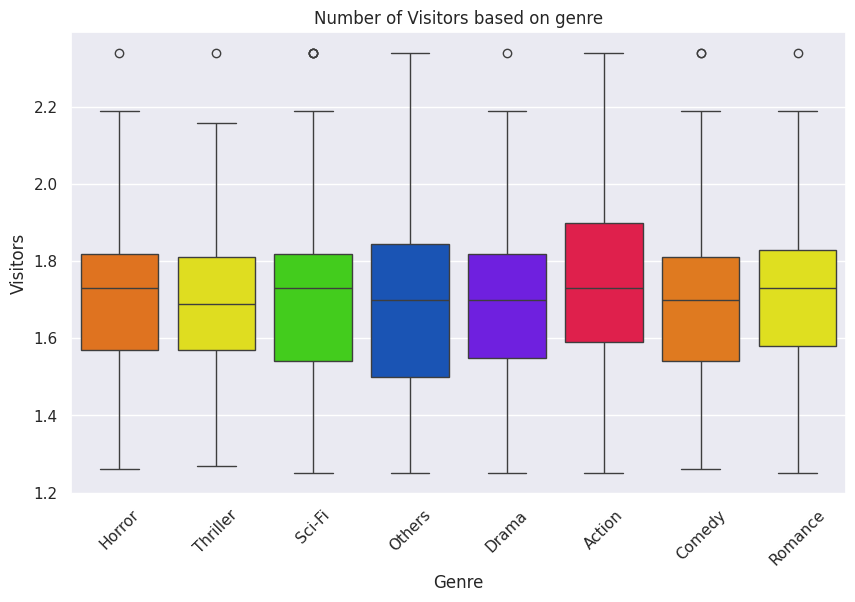

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="genre", y="visitors", hue = "genre", palette = "prism", legend=False)
plt.title("Number of Visitors based on genre")
plt.xlabel("Genre")
plt.ylabel("Visitors")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Calculate actual statistics
visitor_stats = df.groupby('genre')['visitors'].agg([
    'count', 'mean', 'median', 'min', 'max', 'std'
])

print(visitor_stats)

          count      mean  median   min   max       std
genre                                                  
Action      101  1.740891    1.73  1.25  2.34  0.255946
Comedy      114  1.697456    1.70  1.26  2.34  0.254711
Drama       109  1.698440    1.70  1.25  2.34  0.210384
Horror      101  1.712376    1.73  1.26  2.34  0.216338
Others      255  1.690745    1.70  1.25  2.34  0.240437
Romance     105  1.716381    1.73  1.25  2.34  0.207513
Sci-Fi      102  1.707941    1.73  1.25  2.34  0.245451
Thriller    113  1.692920    1.69  1.27  2.34  0.209999


**Observations**
* Action genre has the maximum visitors on an average (1.74 M).
* Other top performing genres on an average are  Horror (1.71M), Sci-Fi (1.70M), Romance: 1.71M).
* Drama, Comedy, Others and Thriller genres as have relatively low visitors (approximately 1.69M) as compared to top genres attracting visitors.
* The box plot shows outliers for all genres having visitors above 2.2M except Others.
* Overall, clear viewer preference for Action, horror, Sci-fi and romance content.


**genre vs views_content**

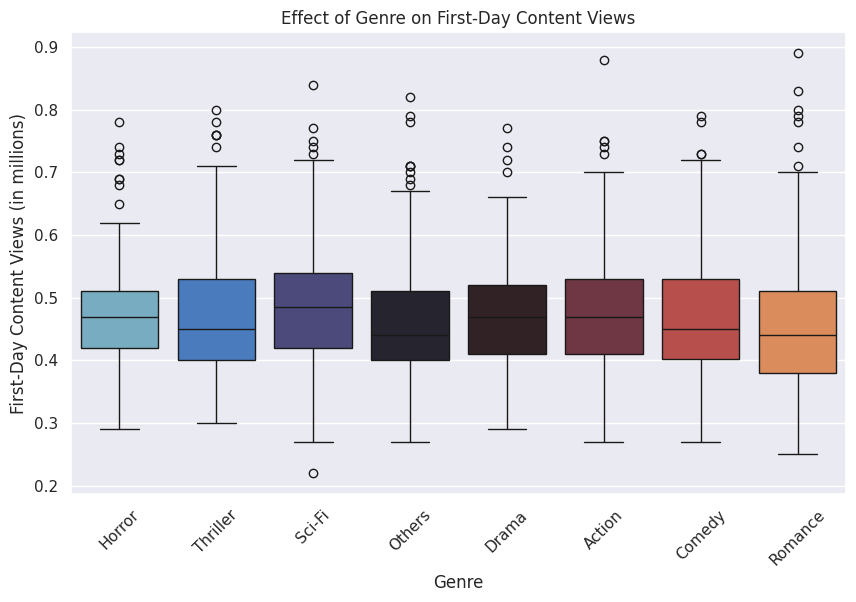

          count      mean
genre                    
Action      101  0.487327
Comedy      114  0.474211
Drama       109  0.473945
Horror      101  0.481089
Others      255  0.459765
Romance     105  0.461238
Sci-Fi      102  0.493235
Thriller    113  0.476903


In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='genre', y='views_content', data=df, hue = 'genre', palette='icefire',legend=False)
plt.title('Effect of Genre on First-Day Content Views')
plt.xlabel('Genre')
plt.ylabel('First-Day Content Views (in millions)')
plt.xticks(rotation=45)
plt.show()

# Grouped mean of views_content by genre
views_by_genre = df.groupby('genre')['views_content'].agg([
    'count', 'mean'])
print(views_by_genre)

**Observations:**

* The box plot shows that different genres have different impacts on first-day content views.
* Sci-Fi, Horror and Thriller are top performing genres in terms of first-day content viewership on an average (0.49M, 0.48M and 0.47M) even though their counts for content release is less compared to Other (count = 255).
* Others (0.45M) and Romance (0.46) has the lowest mean viewership.
* Understanding the popularity of different genres can help in content strategy.

**major_sports_event vs. views_content**

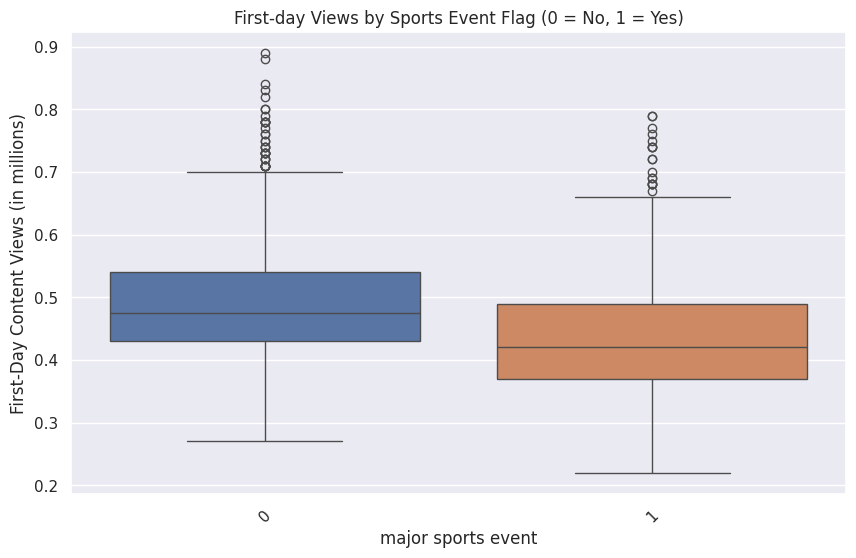



                    count    mean
major_sports_event               
0                     600  0.4938
1                     400  0.4428


In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='major_sports_event', y='views_content', hue= 'major_sports_event', legend=False)
plt.title('First‑day Views by Sports Event Flag (0 = No, 1 = Yes)')
plt.xlabel('major sports event')
plt.ylabel('First-Day Content Views (in millions)')
plt.xticks(rotation=45)
plt.show()

# Group means
print('\n')
print(df.groupby('major_sports_event')['views_content'].agg([
    'count', 'mean']))

**Observations**
* The mean First-day content views when no sports event is 0.49M, while for major sport event day view is 0.44M.
* There are several outliers on upper whiskers of both the box plots.
* Outliers on non-sports day shows viewership ranging between 0.7-0.9M, while for sport event day it ranges between 0.65M-0.8M.
* This suggests there is significant impact of sports even on the first-day as it results in reduced content viewership.

**daysofweek vs genre**

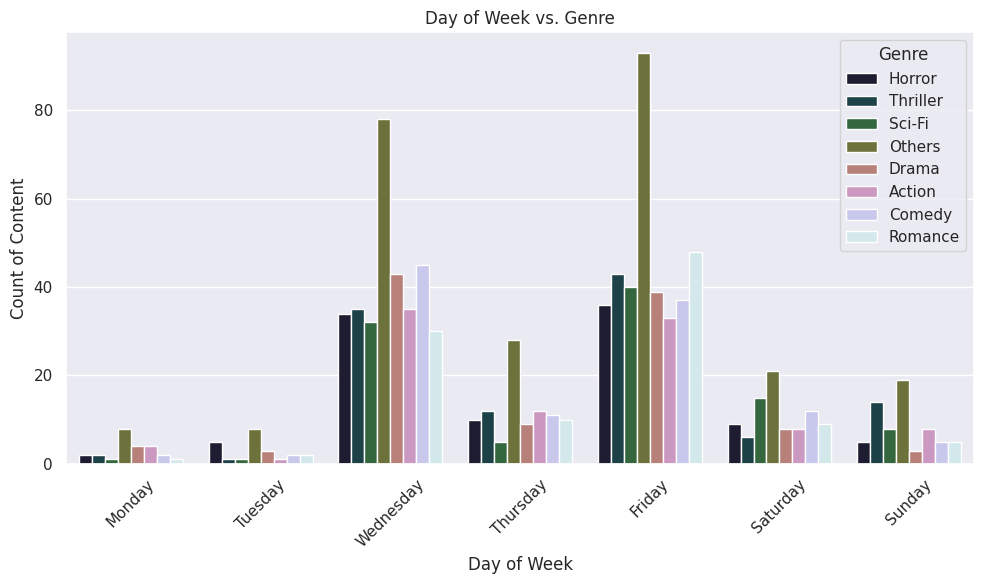

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='dayofweek', hue='genre', palette='cubehelix', order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title('Day of Week vs. Genre')
plt.xlabel('Day of Week')
plt.ylabel('Count of Content')
plt.legend(title='Genre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observations**
* **Friday and Wednesday** have the biggest number of content releases in most genres.
* **Drama, Comedy, and Others** are the most popular genres on high-traffic days, such as Wednesday and Friday.
* **Action and Thriller** content is more evenly distributed, with modest surges on  Friday and Wednesdays.
* **Horror and Sci-Fi** are more common on mid-to-late weekdays, whereas **Romance** has a balanced distribution but is the least popular.
* **Monday and Tuesday** saw the least content releases across all categories.

**Interpretation**
* The platform appears to prefer **Wednesday and Friday** for delivering high-volume content across different genres, most likely due to audience interaction patterns.
* **Weekends** have moderate genre activity (particularly Action and Sci-Fi), indicating deliberate placements for leisure-time content.
*  Lighter genres, such as **Romance** and **Comedy**, are broadcast midweek, probably targeting casual weekday viewers.
*  This analysis can inform **content scheduling**, **campaign targeting**, and **genre allocation** throughout the week.

##**Q3. The day of the week on which content is released generally plays a key role in the viewership. How does the viewership vary with the day of release?**

**dayofweek vs. views_content**

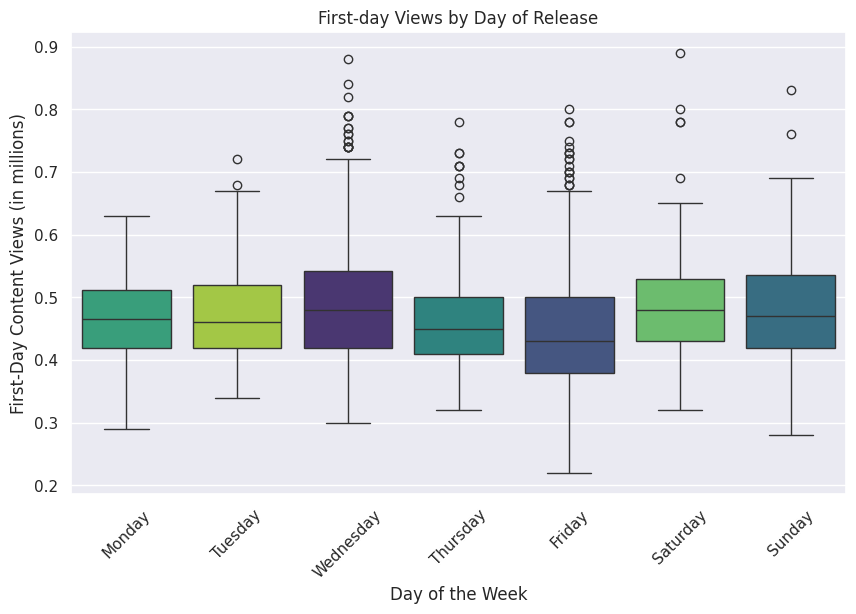



 Mean content views in million by day of week:

               mean     sum
dayofweek                  
Saturday   0.497955   43.82
Wednesday  0.494608  164.21
Tuesday    0.487826   11.22
Sunday     0.484179   32.44
Thursday   0.470619   45.65
Monday     0.467917   11.23
Friday     0.446694  164.83


In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='dayofweek', y='views_content', hue='dayofweek', palette='viridis', order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'], legend=False)
plt.title('First‑day Views by Day of Release')
plt.xlabel('Day of the Week')
plt.ylabel('First-Day Content Views (in millions)')
plt.xticks(rotation=45)
plt.show()

#gouped mean by day of week
print("\n\n Mean content views in million by day of week:\n")
dayofweek_views = df.groupby('dayofweek')['views_content'].agg(['mean','sum'])
print(dayofweek_views.sort_values(by='mean', ascending=False))

**Observations**
* In the boxplot, Saturday has the highest median and the highest average views per content (mean = 0.498M).
* Wednesday exhibits the most variety with several high-performing outliers and ranks closely in mean views (0.495M).
* Despite having the most views overall, Friday has the lowest average views per piece of content (0.447M), suggesting a large volume of releases.
* The fact that Monday and Tuesday have the fewest total views suggests that there may be fewer content drops on those days.
* Wednesday and Friday are the days with the most outliers, suggesting occasional viral content, leading to high first-day viewership.

**Interpretation**
* Viewership fluctuates dramatically each day of the week.
* While Friday has the most releases (total views), it underperforms per-content, indicating content saturation or audience fatigue.
* Saturday is the best day to optimise per-content performance, both in terms of average and boxplot distribution (high median and moderate spread).
* Wednesday is a good midweek candidate because of its high average and frequent spikes, which are probably caused by targeted content.
* Releasing significant or high-ticket content on Saturday or Wednesday may increase engagement.
* Friday may be set aside for larger, lower-priority releases in which performance is less crucial.

**Conclusion**
* The day of release has a distinct and measurable effect on first-day content viewership.  A data-driven scheduling strategy can greatly boost first-day content views performance on the platform.


##**Q4. How does the viewership vary with the season of release?**

**season vs. views_content**

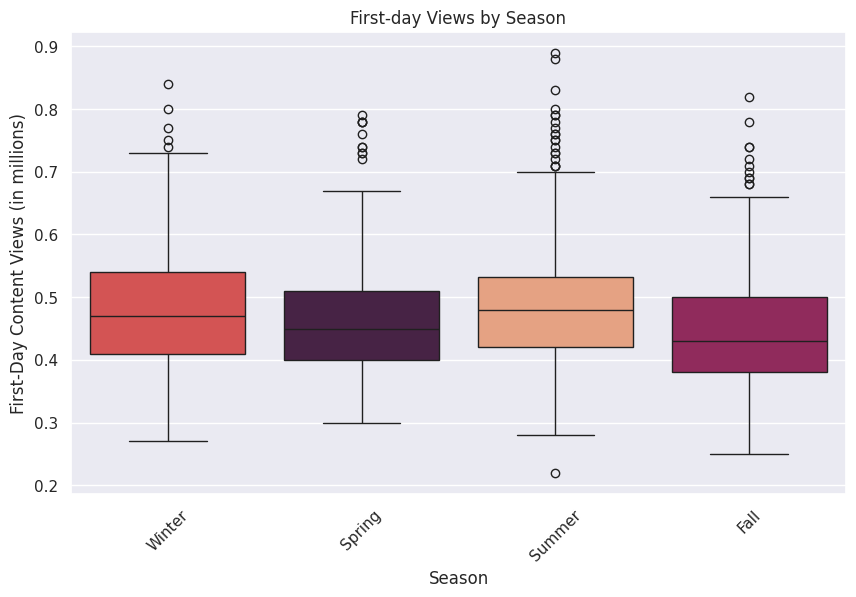


Average views (millions) by season:

            mean
season          
Summer  0.496803
Winter  0.484669
Spring  0.467166
Fall    0.445357


In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='season', y='views_content', hue= 'season',palette='rocket', order=['Winter','Spring','Summer','Fall'], legend=False)
plt.title('First‑day Views by Season')
plt.xlabel('Season')
plt.ylabel('First-Day Content Views (in millions)')
plt.xticks(rotation=45)
plt.show()

#Grouped mean by season
season_means = (df.groupby('season')['views_content']
                  .agg(['mean'])
                 )
print('\nAverage views (millions) by season:\n')
print(season_means.sort_values(by='mean', ascending=False))

**Observations**

*Summer*
* Highest median viewership (0.45M) and mean viewership (0.497M).
* Outliers in both ends of whiskers indicate breakout potential (up to 0.7M+).

*Winter*
* Most consistent performance (narrow IQR). 2.3% below Summer median but reliable with 2nd highest mean viewership (0.485M).
* There are outliers on the upper whiskers in the range of 0.73M-0.85M.

*Spring*
* Spring ranks third in terms of mean (0.467M), with an IQR similar to Winter but a lower median.
* Outliers are present in upper whiskers of viewership range ~(0.71M-0.8M).

*Fall*
* Fall has the lowest mean (0.445M) and median, with a slightly narrower range that centres lower than other seasons.
* Outliers on upper end with viewership in range ~(0.65M-0.82M).

**Summer** and **Winter** have high outliers (≥ 0.85 million), indicating infrequent blockbuster releases.

**Interpretation**
Seasonality affects average first-day views, which vary by around 11% between peak (Summer) and low (Fall) seasons.

Summer advantage: Increased leisure time (school breaks, vacations) is likely to improve engagement, making summer the best period for premium releases.

Winter opportunity: Winter's mean is similar to summer's, implying that vacation breaks and indoor entertainment fuel increased viewership.

Lower averages may indicate conflict with holiday preparations or new TV seasons. Reserve Autumn for lower-priority programs or allocate extra marketing.


**Conclusion**
* Thus, there's also a noticeable difference in the distribution of viewership across different seasons.
* Viewership is highest in the summer and lowest in the fall, with winter and spring in between.
* This suggests that viewers might be more inclined to watch content on ShowTime during Summer, Winter seasons, potentially due to factors like weather or seasonal preferences.
* To maximise opening-day impact, schedule flagship titles in Summer or Winter, and increase promotion for Fall releases to compensate for seasonal headwinds.


##**Q5. What is the correlation between trailer views and content views?**

**views_trailer vs. views_content**

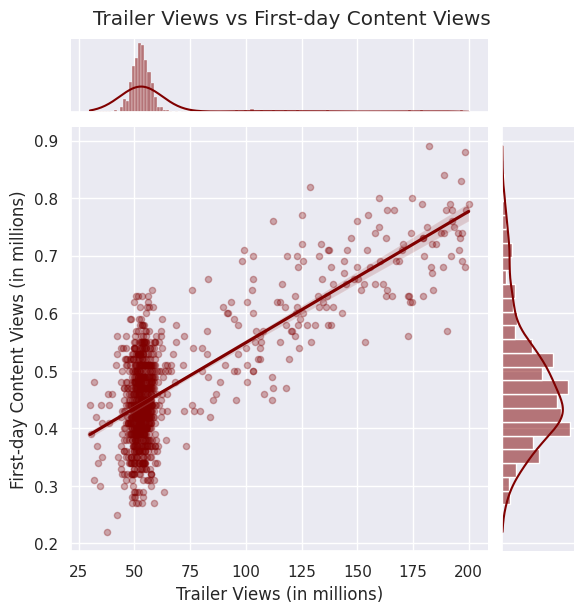

In [ ]:
sns.jointplot(data=df, x='views_trailer', y='views_content', kind='reg', height=6,
              scatter_kws=dict(alpha=0.3, s=20),color='maroon')
plt.suptitle('Trailer Views vs First‑day Content Views', y = 1.02)
plt.xlabel('Trailer Views (in millions)')
plt.ylabel('First‑day Content Views (in millions)')
plt.show();

**Observations**
* The scatter points exhibit a clear upward trend, indicating a strong positive linear relationship because of Correlation (r) = ~0.75M (from the heatmap data above).
* The data clusters around ~50-55 million trailer views and 0.3-0.5 million content views.
* The regression line indicates a positive slope, demonstrating that higher trailer views correlate with higher first-day content views.
* This means that as the number of trailer views increases, so do first-day content views.
* Therefore, promoting trailers effectively can dramatically improve content performance upon debut.

##**Mutivariate Analysis**

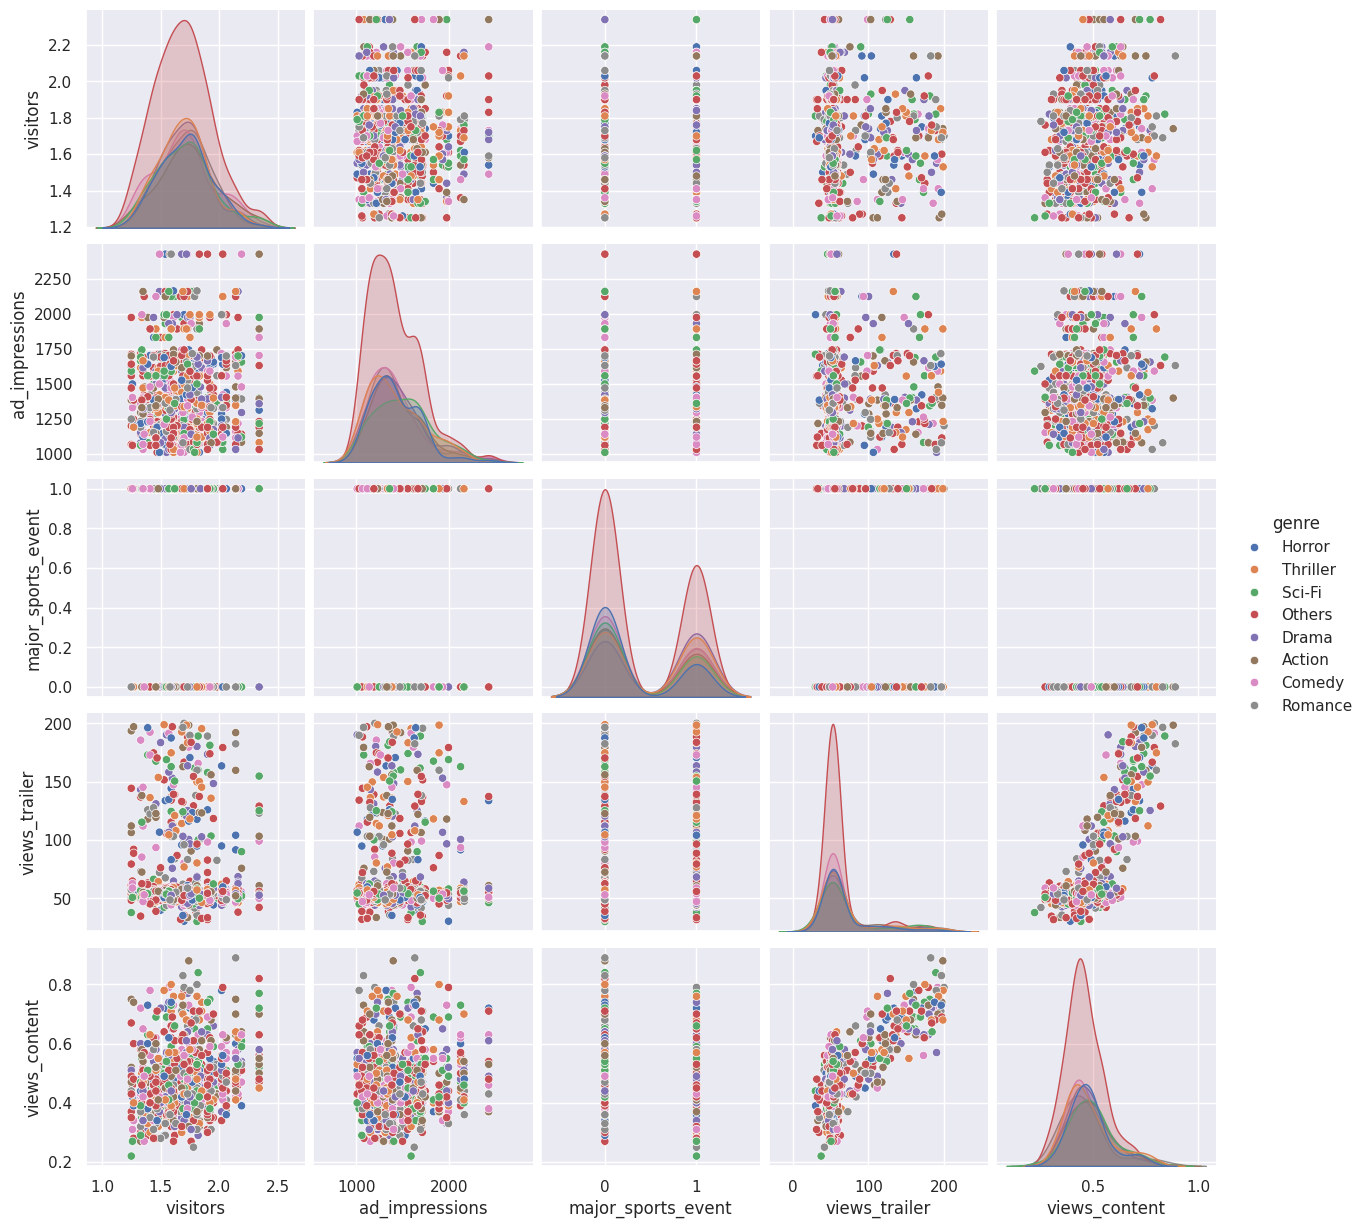

In [ ]:
pair = sns.pairplot(df, hue='genre', diag_kind='auto')
plt.show()

# Save plot as high-resolution image
pair.savefig("pairplot_genre.png", dpi=300, bbox_inches='tight')

**Observations by genre**

*1. views_trailer vs. views_content*

* Sci-Fi and Action genres are clustered on the top right: high trailer buzz leads to higher content views (70M trailer views and 0.55 million content views).
* Romance and comedy are primarily viewed in the bottom-left corner, with lower trailer views and correspondingly lower content views.
* Drama, Others, and Thriller are spread over the range, with no clear clustering.
* Trailer view is a powerful performance driver, particularly in genres such as Sci-Fi and Action.  Genres with little trailer engagement perform poorly on launch day.

*2. ad_impressions vs. views_content*
* Regardless of performance level, all genre colours have a high degree of overlap, with 1.2 billion to 1.6 billion ad impressions.
* No clear vertical division is noted between genres.
* Ad impressions alone are not a significant predictor of genre performance.  * Marketing may spend evenly without regard to genre.

*3. visitors vs.  views_content*
* This pair doesn't focus on any one genre.  
* The distribution of data indicates that visitor volume is consistent across genres.
* Platform-wide visitor statistics are steady and non-genre specific.  
* This shows that visitor count does not explain genre-specific variation.

*4. major_sports_event vs. views_content*
* Because major_sports_event is binary, its columns exhibit no significant genre bias.
* Every genre has points on and off sports event days.
* Content is not released around sports events based on genre.  
* Scheduling appears to be independent of event presence.

*5. Genre Slope Patterns*
* The trailer-content view relationship has a positive slope across all genres, as seen without regression lines.
* The intercept shifts, that is, genres like as sci-fi and action receive more content views at the same trailer level.
* These genres have a higher conversion rate of trailer views to content views, maybe due to strong fan communities.

##**Overall EDA Insights**

**1.Key Performance Indicators**

**The Effect of views_trailer**

* There is a **strong positive correlation (0.75)** between trailer views and first day content views.

* Engagement with trailers is the **most consistent driver** for predicting content performance.

* **Sci-fi and Action** genres have better performance in trailer-to-content conversion rates compared to Romance and Comedy genres which lag behind in both trailer engagement and conversion.

**Timing the Release**

* ***Day of the Week:***

   * Content is released mainly on **Fridays and Wednesdays which constitute 70% of all content releases**.
   * **Saturday has the highest content performance** metrics with **0.498 million** average views per content.

   * **Friday has the lowest content performance** at **0.447 million** views per content, although it has the highest number of releases.

   * On **Monday and Tuesday there is a clear underutilization** trend at 2.3-2.4% of releases.

* ***Viewership by season:***

  * **Summer continues to be the most popular** season for viewership with an average of **0.497M**.  

  * **Winter season is consistent** with winter viewership averaging at **0.485M**.  

  * **Fall is noticeably the weakest season** for viewership at **0.445M**.  

  * There is an **11% difference in performance between summer and fall**.


**2.Genre Performance Metrics**

**Best Performing Genres**  

* **Sci-Fi, Horror, and Thriller** have the highest average first-day viewership (0.47-0.49M).  

* The **Action genre** captures the most unique platform users (1.74M average).  

* These genres show better engagement as well as stronger fan activation and conversion ratios.  

**Genre Distribution**

* The **“others” category dominates** distribution with 26% share of the total content released.  

* **Balanced distribution** across standard genres, each falling within the 10.1 - 11.4% range.  

* **Concentration of content** in unclassified categories.

**3.External Influences**  

**Impact of Sports Events**   
* **Major sport event drops the viewership** around 10% from 0.49 Million to 0.44 million.  

* There is a **moderate negative correlation** (r = -0.24) with performance on first day.  

* Overall platform traffic and ad impressions remain unaffected by sporting events.  

**4.User Involvement & Platform Activities**  

**Content Consumption**  

* The **average first-day view number is around 0.47M** has a moderate right-skew distribution.  

* Some **users are able to achieve 0.7-0.9M views** indicating potential for virality.  

* Most content shows **reliable engagement trends** ranging from mid-concentration to mid-high concentration.  

**Marketing Efficiency**

* **ad impressions shows little impact** on success of content with weak covariation (r = 0.05).

* **Trailer views are 15 times more predictive** than ad volume for content performance.  

**Platform Engagement Trends**

* The number of **daily visitors is consistent** with an average of 1.7 million and very low variance of 0.23 Million.  

* Success of content remains unattainable with **high variability of ad impressions** (SD=289.5).  

* Content performance fails to strongly predict platform traffic as it has **weak correlation with platform traffic** (r=0.26).


**5.Distribution Insights**

**Content Release Strategy Patterns**

* **Seasonal timing bias** for mid-week and weekend transitions.

* **Season is almost uniformly distributed** around a all seasons (24.4-25.7%).

* **Weekend releases have more per-content engagement** than weekday volume.

**Audience Behaviour**

* **Stable platform usage** by visitors regardless of content strategy.
* **Clearly defined* genre preferences** with measurable performance gaps.
* **External event sensitivity** affects content consumption behaviour.












#**DATA PROCESSING**

##**Data Inspection**

In [ ]:
#Creating a copy of our df dataset
df1 = df.copy()
df1.head()

,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
0,1.67,1113.81,0,Horror,Wednesday,Spring,56.70,0.51
1,1.46,1498.41,1,Thriller,Friday,Fall,52.69,0.32
2,1.47,1079.19,1,Thriller,Wednesday,Fall,48.74,0.39
3,1.85,1342.77,1,Sci-Fi,Friday,Fall,49.81,0.44
4,1.46,1498.41,0,Sci-Fi,Sunday,Winter,55.83,0.46


###**Checking Missing values**

In [ ]:
print("Missing Values:")
df1.isnull().sum()


Missing Values:


,0
visitors,0
ad_impressions,0
major_sports_event,0
genre,0
dayofweek,0
season,0
views_trailer,0
views_content,0


* There are no missing values in or dataset.

###**Checking for Duplicates**

In [ ]:
print("Duplicate rows in the dataset:")
df1.duplicated().sum()



Duplicate rows in the dataset:


np.int64(0)

* There are no duplicates data.

##**Outlier Detection and Treatment**

**Note:**  
* **Outlier detection will not done on the major_sports_event variable because it is a binary indication (0 = no, 1 = yes).**  
*Outlier detection technique, such as IQR, is only relevant to continuous numerical variables with a large range of values.  
* Because major_sports_event only accepts two valid values, it has no statistical outliers by definition.

**Outliers Detection**

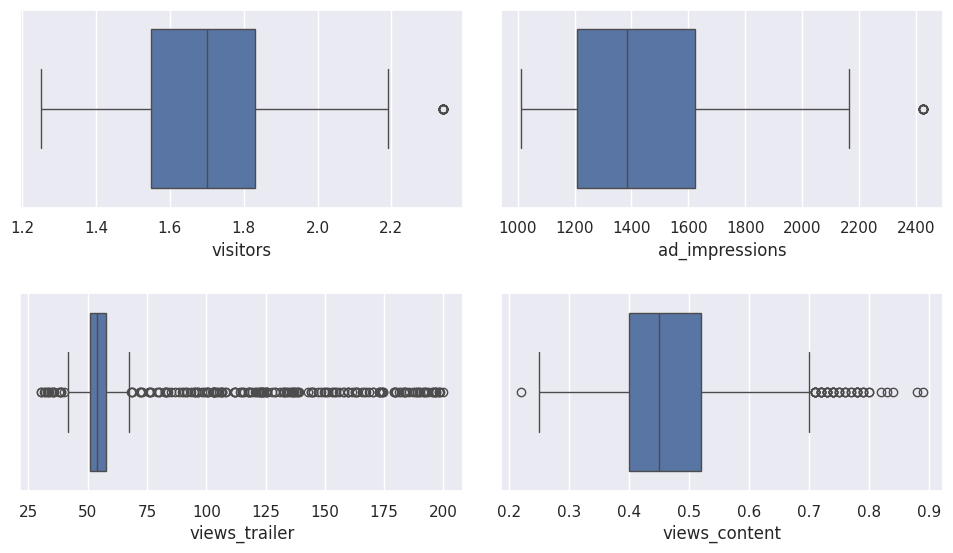

In [ ]:
# get continuous numeric columns
continuous_cols = ['visitors', 'ad_impressions',
                   'views_trailer', 'views_content']

#Visually detecting the outliers using box plot
plt.figure(figsize=(10, 6))
for i, variable in enumerate(continuous_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=df1, x=variable)
    plt.tight_layout(pad=2)

plt.show()

**Observations**

*visitors:* It has one outlier above upper end with range above 2.2M.

*ad_impressions:* It has one outlier on upper whiskers having ad impression more than 2400M.

*views_trailer:* It had several outliers on outside of both upper (75M-200M) and lower whiskers ( less than 50M).

*views_content:* It also has many outliers but less compared to trailer views. Lower end has one  outlier with views less the 0.35M, while upper whiskers outlier range from 0.7M-0.9M approximately.

------------------------------------------------------------------------------

**We will now validate these outliers using IQR method.**

In [ ]:

# perform outlier detection on above columns

# Initialize a dictionary to store outlier information for each column
outlier_report = {}

# Loop through each numerical column to calculate outlier bounds
for col in continuous_cols:
    # Calculate the first quartile (Q1) and third quartile (Q3) for the current column
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)

    # Calculate the Interquartile Range (IQR)
    IQR = Q3 - Q1

    # Determine the lower and upper bounds for outlier detection
    lower_bound = Q1 - 1.5 * IQR  # Lower bound for outliers
    upper_bound = Q3 + 1.5 * IQR  # Upper bound for outliers

    # Identify the outliers in the current column based on the bounds
    outliers = df1[(df1[col] < lower_bound) | (df1[col] > upper_bound)]

    # Store the outlier information in the report dictionary
    outlier_report[col] = {
        'lower_bound': round(lower_bound, 2),  # Round the lower bound to 2 decimal places
        'upper_bound': round(upper_bound, 2),  # Round the upper bound to 2 decimal places
        'outlier_count': len(outliers),        # Count of outliers in the current column
        'outlier_percentage': round(len(outliers) / len(df1) * 100, 1)  # Percentage of outliers
    }

# Generate a DataFrame from the outlier report dictionary and transpose it for better readability
outlier_df = pd.DataFrame(outlier_report).T

# Print the outlier report DataFrame
print(outlier_df)


                lower_bound  upper_bound  outlier_count  outlier_percentage
visitors               1.13         2.25           20.0                 2.0
ad_impressions       590.32      2243.68           13.0                 1.3
views_trailer         40.74        67.97          189.0                18.9
views_content          0.22         0.70           47.0                 4.7


**Observations:**

**visitors**
* It has **2% outliers** i.e. (20/1000).
* Extreme visitor counts could distort relationship with viewership. Since, visitors outlier percentage (2%) is low.
* Therefore, we will use capping (Winsorizing) technique to treat these outliers as it preserve the data without deleting it.

**ad_impressions**
* It has **1.3% outliers** i.e. (13/1000).
* ad_impressions outliers may represent data errors or special campaigns.
* Extreme values may disproportionately influence regression model coefficients.
* Therefore, **we will use Winsorize (capping) technique to treat the outliers** because minimal data loss and it maintains realistic ad impressions range while reducing skewness

**views_trailer**
* It has **18.9% outliers** i.e. (189/1000) which is high outlier percentage.
* This high outlier count makes capping/removal problematic.
* Therefore, **we will use Log transformation technique to treat the outliers** as it reduces skew while retaining all data points.
* This technique also ensures linear regression assumptions (normality) are met

**views_content**(target variable)
* Views_content has **4.7% outliers** i.e. (47/1000).
* These **outliers could represent genuine high/low viewership events** (e.g., viral hits or flops).
* Removing them would bias the model by ignoring critical real-world scenarios.
* Any transformations on the target can distort predictions.
* Therefore, **we will not treat this outliers for views_content variable**.

**Outliers Treatment**

In [ ]:
#Treatment for visitor- capping outliers
df1['visitors'] = np.clip(
    df1['visitors'],
    a_min=1.13,  #lower bound value rom outlier report above.
    a_max=2.25   #upper bound value from outlier report above
)

#Treatment for ad_impressions- capping outliers
df1['ad_impressions'] = np.clip(
    df1['ad_impressions'],
    a_min=590.32, #lower bound value from outlier report above
    a_max=2243.68  #upper bound value from outlier report above
)


# Treatment for 'views_trailer'- log transformation (18.9% outliers)

df1['views_trailer'] = np.log1p(df1['views_trailer'])  # log(1+x) handles zeros

**Verification Post-Treatment of Outliers:**

In [ ]:
# Check remaining outliers
for col in ['visitors', 'ad_impressions', 'views_trailer']:
    q1 = df1[col].quantile(0.25)
    q3 = df1[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df1[(df[col] < q1 - 1.5*iqr) | (df1[col] > q3 + 1.5*iqr)]
    print(f"{col}: {len(outliers)/len(df1):.1%} outliers remaining")

visitors: 0.0% outliers remaining
ad_impressions: 0.0% outliers remaining
views_trailer: 17.0% outliers remaining


**We will do visual confirmation for treated outliers.**

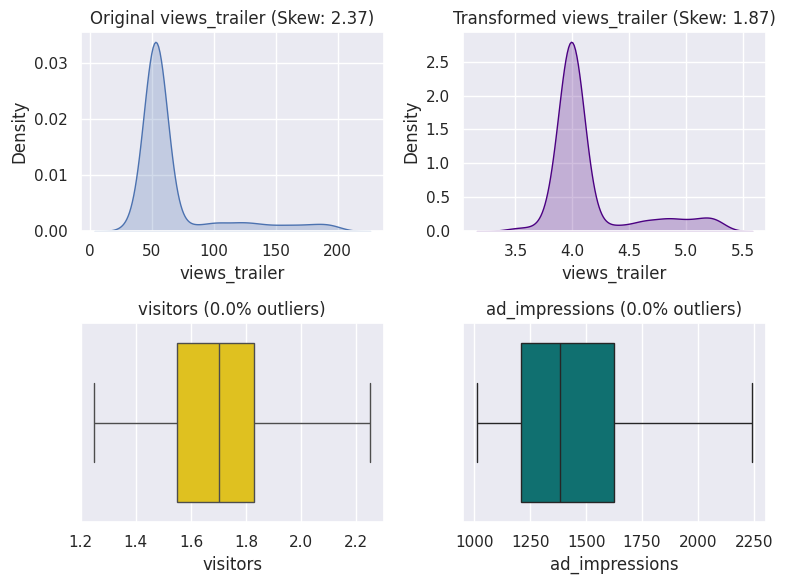

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

# Before-after comparison for views_trailer original(copied df)

#Original data (df1) before transformation and fill the area under curve.
sns.kdeplot(df['views_trailer'], ax=axes[0,0], fill=True) #plot Position in top-left using ax=axes[0,0]
# Calculate skewness for original data using skew()
axes[0,0].set_title('Original views_trailer (Skew: %.2f)' % df['views_trailer'].skew())

# Before-after comparison for views_trailer copied df1

# Transformed data (df1) after transformation and fill the area under curve.
sns.kdeplot(df1['views_trailer'], ax=axes[0,1], color = 'indigo',fill=True) #plot Position in top-right using ax=axes[0,1]
# Calculate skewness for original data using skew()
axes[0,1].set_title('Transformed views_trailer (Skew: %.2f)' % df1['views_trailer'].skew())


# Boxplot verification

sns.boxplot(x=df1['visitors'], ax=axes[1,0],color = 'gold') # Position in bottom-left
axes[1,0].set_title('visitors (0.0% outliers)')

sns.boxplot(x=df1['ad_impressions'], ax=axes[1,1],color = 'teal')# Position in bottom-right
axes[1,1].set_title('ad_impressions (0.0% outliers)')

plt.tight_layout()
plt.show()


**Observations**
* We can clearly see that there are no remaining outliers for visitors and ad_impressions from statistical and visual evidences.
* We can also see there is reduced outliers for views_trailer from 18.9% to 17%. These remaining outliers are business outliers and are in  optimal range now.


**Insights**

***Success Criteria Met:***
* Winsorizing completely resolved outliers for two features (visitors and ad_impressions).
*Log transformation reduced skewness in views_trailer by approximately 50% (a normal outcome).

***views_trailer 17% remaining outlier is okay because:***
* These are no longer statistical outliers, but business outliers: trailers that truly performed exceptionally well or poorly.
* Their reduced magnitude upon transformation minimises impact on the model.
* Removing them would lose key success and failure situations.

##**Feature Engineering**

* We know that in genre 'Others' has unspecified categories (~26% of data) and it could dominate or obscure patterns, and may create multicollinearity issue.
* We will consider this for feature engineering to avoid such issues.
* Instead of removing this data, we create a new binary variable other_genre that:
   * Takes the value 1 if the genre is "Others"
   * Takes the value 0 otherwise

* This allows the model to assess whether being part of this ambiguous category impacts viewership, without distorting the rest of the genre features.

In [ ]:
# df1 = transformed dataset
df2 = df1.copy()       #copying df1

# Flag the ambiguous “Others” genre
df2['other_genre'] = (df2['genre'] == 'Others').astype(int)

df2.head()


,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content,other_genre
0,1.67,1113.81,0,Horror,Wednesday,Spring,4.055257,0.51,0
1,1.46,1498.41,1,Thriller,Friday,Fall,3.983227,0.32,0
2,1.47,1079.19,1,Thriller,Wednesday,Fall,3.906809,0.39,0
3,1.85,1342.77,1,Sci-Fi,Friday,Fall,3.928093,0.44,0
4,1.46,1498.41,0,Sci-Fi,Sunday,Winter,4.040064,0.46,0


In [ ]:
df2['other_genre'].value_counts()

,count
other_genre,
0,745
1,255


**Observations**
* 255 counts (25.5%) belong to the "Others" genre

* 745 counts (74.5%) are specific genres (Actions, Horror, Thriller, etc.)

###**Data Preparation for Modeling**

**Converting the categorical variables to numerical using One-Hot Encoding**

In [ ]:
# One‑hot encode (booleans)
df_encod = pd.get_dummies(df2,
                          columns=['genre', 'dayofweek', 'season'],
                          drop_first=True)

# Remove duplicate 'genre_Others' dummy
df_encod.drop(columns=['genre_Others'], inplace=True, errors='ignore')

# Convert booleans to 0/1 integers
bool_columns = df_encod.select_dtypes(include=['bool']).columns
df_encod[bool_columns] = df_encod[bool_columns].astype(int)


df_encod.head()


,visitors,ad_impressions,major_sports_event,views_trailer,views_content,other_genre,genre_Comedy,genre_Drama,genre_Horror,genre_Romance,...,genre_Thriller,dayofweek_Monday,dayofweek_Saturday,dayofweek_Sunday,dayofweek_Thursday,dayofweek_Tuesday,dayofweek_Wednesday,season_Spring,season_Summer,season_Winter
0,1.67,1113.81,0,4.055257,0.51,0,0,0,1,0,...,0,0,0,0,0,0,1,1,0,0
1,1.46,1498.41,1,3.983227,0.32,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,1.47,1079.19,1,3.906809,0.39,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
3,1.85,1342.77,1,3.928093,0.44,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1.46,1498.41,0,4.040064,0.46,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1


In [ ]:
print("Null values:")
df_encod.isnull().sum()

Null values:


,0
visitors,0
ad_impressions,0
major_sports_event,0
views_trailer,0
views_content,0
other_genre,0
genre_Comedy,0
genre_Drama,0
genre_Horror,0
genre_Romance,0


* There are no null values in our encoded dataset.

#**MODEL BUILDING - LINEAR REGRESSION**

* **In this section first we need to select our target variable from the dataframe and separate it from the independent variables(predictors).**

In [ ]:
#selects input features (or predictors)
X = df_encod.drop('views_content', axis=1)
#select your target variable (dependent var).
y = df_encod['views_content']


* **Adding the intercept value.**

In [ ]:
# add constant (intercept term)
X_const = sm.add_constant(X)   # keeps all original columns, plus 'const'

* **Splitting the data into train and test set:**

   * x_train → 70% of feature data used to train the model

   * x_test → 30% of feature data used to test (evaluate) the model

   * y_train → Target values for x_train

   * y_test → Target values for x_test

In [ ]:
# splitting the data in 70:30 ratio for train to test data

x_train, x_test, y_train, y_test = train_test_split(X_const, y, test_size=0.3, random_state=1)

#Note: Use X_const (not plain X) in train_test_split

* **Checking shape of train and test dataset.**

In [ ]:
print("Number of rows in train data =", x_train.shape[0])
print("Number of rows in test data =", x_test.shape[0])

Number of rows in train data = 700
Number of rows in test data = 300


* **Original Model builing using Linear Regression.**

In [ ]:
olsmodel = sm.OLS(y_train, x_train).fit()
print(olsmodel.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.783
Method:                 Least Squares   F-statistic:                     126.9
Date:                Wed, 09 Jul 2025   Prob (F-statistic):          1.01e-213
Time:                        10:03:25   Log-Likelihood:                 1120.1
No. Observations:                 700   AIC:                            -2198.
Df Residuals:                     679   BIC:                            -2103.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.6983    

**Model Coefficients**

In [ ]:
# Create a DataFrame of coefficients with column names

olsmodel_coef_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Coefficient": olsmodel.params.values
})

# Display the DataFrame
olsmodel_coef_df


,Feature,Coefficient
0,const,-0.698283
1,visitors,0.129802
2,ad_impressions,0.000004
3,major_sports_event,-0.062978
4,views_trailer,0.221061
5,other_genre,0.005775
6,genre_Comedy,0.008727
7,genre_Drama,0.010071
8,genre_Horror,0.008342
9,genre_Romance,0.001179


##**Interpreting the Regression Results for Original Model**

1. **R-squared**:
   * In our case value is  0.789.
   * It means that 78.9% of the total variance in views_content is explained by the specific independent variables in the model.


2. **Adjusted. R-squared**: It reflects the fit of the model.
    * Adjusted R-squared values generally range from 0 to 1, where a higher value generally indicates a better fit, assuming certain conditions are met.
    * In our case, the value for adj. R-squared is **0.783**, which is good, suggest good fit model.
    * A result of 0.783 shows that the model explains 78.3% of the variation in first-day viewing, even after controlling for various factors. This shows an excellent model fit.


3. ***const* coefficient**: It is the Y-intercept.
    * It means that if all the predictor variable coefficients are zero, then the expected output (i.e., Y) would be equal to the *const* coefficient.
    * In our case, the value for `const` coefficient is **-0.6983.**
    * Since, this value is negative, it has no direct practical meaning in this context (all predictors being zero is implausible), yet it is mathematically required for the model.

4. **F-statistic**:
   * F-statistic = 126.9.
   * Probability (F-statistic): 1.01e-213.
   * This demonstrates that the entire model is statistically significant.  
   * The very low p-value implies that at least one predictor variable is significantly associated with the response variable.


5. **Coefficient of a predictor variable**: It represents the change in the output Y due to a change in the predictor variable (everything else held constant). We have total of 20 features in this model. Example:
    * In our case, the coefficient of **views_trailer** is **0.2211**. This means for every additional 1 million trailer views raises the first-day view total by an average of 0.221 million (221k).
    * For the coefficient of '***visitors***'is **0.1298**. This means for every 1 million additional platform visitors, there are around 130k more first-day content views.
    * For the coefficient of **major_sports_event** is **-0.0630**, suggesting launching content during a sporting event reduces views by around 63k.
    * For **genre_Sci-Fi** with coefficient value of **0.0162**, indicates Sci-Fi content performs somewhat better than the base genre (Action), resulting in around 16k extra views.
    * For the coefficient of **dayofweek_Saturday** is **0.0570**, shows Saturday releases generate ~57k more views than Friday (baseline).
    * Other categorical factors (days and seasons) have similar interpretations, with significant ones (p-value < 0.05) having a considerable impact on viewing.

6. **Non-significant Variables**:
   * **ad_impressions, other_genre, and most genre dummies have strong p-values (p > 0.05)**, indicating that they have **no statistically significant effect on first-day views** when other factors are held constant.
   * This could be due to overlap or multicollinearity with more significant variables, such as views_trailer.



##**Original Model Performance Check**

Let's check the performance of the model using different metrics.

* We will be using metric functions defined in sklearn for RMSE, MAE, and $R^2$.
* We will define a function to calculate MAPE and adjusted $R^2$.
    * The mean absolute percentage error (MAPE) measures the accuracy of predictions as a percentage, and can be calculated as the average absolute percent error for each predicted value minus actual values divided by actual values. It works best if there are no extreme values in the data and none of the actual values are 0.
    
* We will create a function which will print out all the above metrics in one go.

In [ ]:
# REGRESSION‑MODEL EVALUATION

# helper function 1: adjusted‑R²

def adjusted_r2(X_matrix, y_true, y_pred):
    """
    Compute Adjusted R‑squared, where
    X_matrix : DataFrame of predictors (n rows × k cols)
    y_true   : Series of actual target values
    y_pred   : 1‑D array of predictions from the model

    Returns float Adjusted R² value.
    """
    r2 = r2_score(y_true, y_pred)         # ordinary R²
    n  = X_matrix.shape[0]                # sample size
    k  = X_matrix.shape[1]                # number of predictors
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)


#  helper function 2: MAPE (mean‑absolute‑percentage‑error)

def mean_absolute_percentage_error(y_true, y_pred):
    """
    Compute MAPE (average absolute percentage difference).
    """
    # prevent division by zero if any actual value is zero
    y_true_safe = np.where(y_true == 0, np.finfo(float).eps, y_true)
    pct_errors  = np.abs(y_true_safe - y_pred) / y_true_safe
    return pct_errors.mean() * 100



# MAIN FUNCTION: evaluate_regression

def evaluate_regression(model, X, y):
    """
    Generate a one‑row DataFrame of regression performance metrics. Here,
    model : statsmodels or sklearn regressor that has .predict()
    X     : predictors for which you want predictions (DataFrame or array)
    y     : actual target values (Series or array)

    Returns DataFrame with columns: RMSE, MAE, R-squared, Adj. R-squared, MAPE

    """
    # Make predictions
    y_hat = model.predict(X)

    # Compute metrics
    rmse  = np.sqrt(mean_squared_error(y, y_hat))
    mae   = mean_absolute_error(y, y_hat)
    r2    = r2_score(y, y_hat)
    adjr2 = adjusted_r2(X, y, y_hat)
    mape  = mean_absolute_percentage_error(y, y_hat)

    # Return tidy DataFrame
    return pd.DataFrame(
        {
            "RMSE":  [rmse],
            "MAE":   [mae],
            "R-squared":      [r2],
            "Adj. R-squared": [adjr2],
            "MAPE (%)":       [mape],
        }
    )


In [ ]:
# checking model performance on train set (seen 70% data)
olsmodel_train_perf = evaluate_regression(olsmodel, x_train, y_train)

# checking model performance on test set (seen 30% data)
olsmodel_test_perf  = evaluate_regression(olsmodel, x_test,  y_test)

print(" Original Model Performance:\n")
perf_table = pd.concat([olsmodel_train_perf, olsmodel_test_perf], axis=0)
perf_table.index = ["Train", "Test"]
print(perf_table)

 Original Model Performance:

           RMSE       MAE  R-squared  Adj. R-squared  MAPE (%)
Train  0.048844  0.038426   0.788913        0.782374  8.549048
Test   0.050487  0.040592   0.767519        0.749958  9.009553


**Observations & Interpretations**

**1. RMSE (Root Mean Squared Error):**
  * **Train = 0.0488**
  * **Test = 0.0505.**
  * The target variable (views_content) spans from 0.2M to 0.9M, resulting in an average prediction error of roughly 50,000 views (RMSE ~ 0.05).
  * The acceptable range for RMSE in this situation is <0.05 = Excellent, 0.05-0.10 = Good.
  * Our numbers are in the **Excellent-Good range**.

**2. Mean Absolute Percentage Error (MAPE):**
  * **Train MAPE = 8.549(8.55%)**
  * **Test MAPE = 9.009 (9.01%)**.
  * This indicates that, on average, our predictions and the actual results differ by about 9%.
  * Our model fulfils the best-practice standard, with an **acceptable MAPE range of <10% (excellent)**.

3. **R-squared and adjusted R-squared:**
    *R-squared Train = 0.789
    *R-squared Test = 0.767
    * This indicates our approach accounts for roughly 76-79% of the variation in first-day content views.
    *Adjusted R² reflects the number of predictors:
        * Adj. R² Train = 0.782
        * Adj. R² Test = 0.749
        * The slight drop from train to test is normal and acceptable.

    * Acceptable R² varies by context, however with business data, R² > 0.75 is regarded strong.


**Conclusion**
* Model fits well, as evidenced by its performance on the test set, which is highly similar to the training set.
* No considerable overfitting is detected.
* Errors are low and within acceptable limits.
* This suggests that the model is resilient, dependable, and capable of making predictions based on previously unseen data for far.

#**CHECKING LINEAR REGRESSION ASSUMPTIONS**

We will be checking the following Linear Regression assumptions:

1. **No Multicollinearity**

2. **Linearity of variables**

3. **Independence of error terms**

4. **Normality of error terms**

5. **No Heteroscedasticity**

###**Test for Multicollinearity.**

* Multicollinearity occurs when predictor variables in a regression model are correlated.

* There are different ways of detecting (or testing) multicollinearity. One such way is by using the Variance Inflation Factor, or VIF.
    * If VIF is between 1 and 5, then there is low multicollinearity.
    * If VIF is between 5 and 10, we say there is moderate multicollinearity.
    * If VIF is exceeding 10, it shows signs of high multicollinearity.

In [ ]:
#Define a function to check VIF.
def get_vif_df(X: pd.DataFrame) -> pd.DataFrame:  #X is expected to be a pandas DataFrame, -> used for hinting syntax that it is expecting df here
    """
    Compute Variance Inflation Factors for every numeric column
    in a predictor matrix.
    X : DataFrame that contains only the predictor variables
        used in the regression model (including 'const').

    Returns DataFrame with two columns:'feature' – original column names
     and 'VIF'– variance‑inflation‑factor value

    """

    # container for results
    vif_data = {
        "feature": [],
        "VIF": []
    }

    # enumerate over column indices
    for i, col in enumerate(X.columns):
        vif_value = variance_inflation_factor(X.values, i)
        vif_data["feature"].append(col)
        vif_data["VIF"].append(vif_value)

    return pd.DataFrame(vif_data)

In [ ]:
vif_df = get_vif_df(x_train)
print(vif_df.sort_values("VIF", ascending=False))


                feature         VIF
0                 const  235.813072
5           other_genre    2.573661
7           genre_Drama    1.925017
11       genre_Thriller    1.920533
6          genre_Comedy    1.917612
8          genre_Horror    1.903682
10         genre_Sci-Fi    1.864272
9         genre_Romance    1.753434
20        season_Winter    1.569560
19        season_Summer    1.566865
18        season_Spring    1.541060
17  dayofweek_Wednesday    1.316002
15   dayofweek_Thursday    1.170615
13   dayofweek_Saturday    1.155980
14     dayofweek_Sunday    1.150704
3    major_sports_event    1.067316
12     dayofweek_Monday    1.063398
16    dayofweek_Tuesday    1.062225
2        ad_impressions    1.029726
1              visitors    1.026610
4         views_trailer    1.024779


**Observations:**
* **There is no significant multicollinearity in the model**, as seen by the VIF values of all predictor variables (except from constant), which are much below the VIF <= 5 .
* Hence, the assumption is satisfied.

###**Dealing with high p-value variables.**

* Some of the dummy variables in the data have p-value > 0.05. So, they are not significant and we'll drop them one at a time as sometimes p-values change after dropping a variable
* Instead, we will do the following:
    * Build a model, check the p-values of the variables, and drop that variable from your dataset.
    * Re-fit the model using the updated dataset (with the dropped column).
    * Repeat the above two steps till there are no columns with p-value > 0.05



In [ ]:
# Make a copy of training predictors
X_filtered = x_train.copy() #x_train has our 70% training input features

# Store column names
remaining_features = X_filtered.columns.tolist()

# Loop to eliminate features with high p-values
while True:
    # Subset data using remaining features
    X_train_temp = X_filtered[remaining_features]

    # Fit the OLS model
    model = sm.OLS(y_train, X_train_temp).fit()

    # Get p-values of all predictors in the model
    pvals = model.pvalues

    # Identify the feature with the highest p-value
    highest_pval = pvals.max()
    worst_feature = pvals.idxmax()

    # If the highest p-value is greater than threshold (e.g., 0.05), drop it
    if highest_pval > 0.05:
        print(f"Dropping '{worst_feature}' with p-value {highest_pval:.4f}")
        remaining_features.remove(worst_feature)
    else:
        print("All remaining features are significant (p ≤ 0.05)")
        break

# Final list of features with acceptable p-values
final_features = remaining_features
print("\nSelected features for final model:", final_features)


Dropping 'genre_Romance' with p-value 0.8897
Dropping 'ad_impressions' with p-value 0.5354
Dropping 'other_genre' with p-value 0.3765
Dropping 'genre_Thriller' with p-value 0.4600
Dropping 'genre_Horror' with p-value 0.5319
Dropping 'genre_Comedy' with p-value 0.5275
Dropping 'genre_Drama' with p-value 0.4434
Dropping 'genre_Sci-Fi' with p-value 0.0888
Dropping 'dayofweek_Tuesday' with p-value 0.0618
All remaining features are significant (p ≤ 0.05)

Selected features for final model: ['const', 'visitors', 'major_sports_event', 'views_trailer', 'dayofweek_Monday', 'dayofweek_Saturday', 'dayofweek_Sunday', 'dayofweek_Thursday', 'dayofweek_Wednesday', 'season_Spring', 'season_Summer', 'season_Winter']


Now we will be preparing refined train and test datasets (x_train1 and x_test1) to build a final regression model with only significant features that are left after we dropped the bad features.

In [ ]:
x_train1 = x_train[final_features] #updated trained dataset
x_test1 = x_test[final_features] #updated test dataset

olsmod2 = sm.OLS(y_train, x_train1).fit()  #ols model fitting
print(olsmod2.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.786
Model:                            OLS   Adj. R-squared:                  0.783
Method:                 Least Squares   F-statistic:                     229.7
Date:                Wed, 09 Jul 2025   Prob (F-statistic):          8.48e-222
Time:                        10:03:25   Log-Likelihood:                 1115.3
No. Observations:                 700   AIC:                            -2207.
Df Residuals:                     688   BIC:                            -2152.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.6842    

In [ ]:
# checking model performance on train set (seen 70% data)
olsmod2_train_perf = evaluate_regression(olsmod2, x_train1, y_train)

# checking model performance on test set (seen 30% data)
olsmod2_test_perf  = evaluate_regression(olsmod2, x_test1,  y_test)

print("Updated Model Performance:\n")
perf_table1 = pd.concat([olsmod2_train_perf, olsmod2_test_perf], axis=0)
perf_table1.index = ["Train", "Test"]
print(perf_table1)

Updated Model Performance:

           RMSE       MAE  R-squared  Adj. R-squared  MAPE (%)
Train  0.049184  0.038688   0.785965        0.782227  8.603114
Test   0.050850  0.040957   0.764165        0.754304  9.114764


**Updated Model Observations & Interpretations w.r.t Train Data**


**1. R-squared and Adjusted  R-squared:**
  
   * The **original mode**l had an R-squared of 0.789, while the adjusted R-squared was 0.783, indicating that the model explained approximately 78.3% of the variation in first-day content views.
   * In the **updated model** R-squared dropped marginally to 0.786 (after deleting high p-value predictors) and Adjusted R-squared to 0.782.
   * The model is now cleaner, with just statistically significant variables remaining, thus this slight decrease (~0.001) is acceptable.
   * The model explains approximately 78.6% of the variability in first-day content views.
   * Both values are extremely close, showing that there is no overfitting due to insignificant predictors.

**2. Model coefficients (significance):**
  * All predictors now have p-values < 0.05, indicating that all variables in the model are statistically significant.
  * Key variables with the biggest influence (high t-values) is views_trailer (t ≈ 42) is the primary driver of viewership.
  * Predictors: visitors, major_sports_event, dayofweek_Wednesday, and season_Summer all contribute significantly.

**3. Error Metrics:**

* *Original model*
 * The RMSE (Test) is around 0.0504, indicating that predictions are off by approximately 50,400 views on average.
 * MAPE (Test) = 9.01%, means predictions are ~9% off the actuals values.

* *Updated model*
  
  * RMSE (Test) is around 0.0508. The error is slightly larger, but still acceptable at approximately 50,800 views.
  * MAPE (Test) = 9.11%, close to actuals, with an average error of around 9%.

* These little deviations demonstrate that model accuracy is maintained even after decreasing predictors.

------------------------------------------------------------------------------


**Now we'll check the rest of the assumptions on *olsmod2*.**

2. **Linearity of variables**

3. **Independence of error terms (residuals)**

4. **Normality of error terms (residuals)**

5. **No Heteroscedasticity**

###**Test for Linearity of variables and Independence of residuals**

* Linearity refers to a straight-line relationship between two variables. Predictor variables must have a linear relationship with the dependent variable.  
* The independence of the error terms (or residuals) is crucial.  If the residuals are not independent, the confidence intervals for coefficient estimates will be reduced, leading us to wrongly conclude that a parameter is statistically significant.
* Create a plot of fitted values vs residuals.  If the residuals do not follow a pattern, the model is linear and independent.
* Otherwise, the model shows evidence of nonlinearity, and the residuals are not independent.
* If the linearity and independence assumptions are not satisfied then we can try to transform the variables and make the relationships linear.

In [ ]:
#Prepare a DataFrame with actual, fitted and residual values
df_pred  = pd.DataFrame({
    "Actual_Values": y_train,                               # actual target values of train data
    "Predicted_Values": olsmod2.fittedvalues,                 # predicted by model of train data
    "Residuals": olsmod2.resid                            # resid calculates residuals (errors) as the difference between actual and predicted values.
})

# top 5 rows
df_pred.head()


,Actual_Values,Predicted_Values,Residuals
731,0.40,0.441486,-0.041486
716,0.70,0.691754,0.008246
640,0.42,0.438357,-0.018357
804,0.55,0.589136,-0.039136
737,0.59,0.547973,0.042027


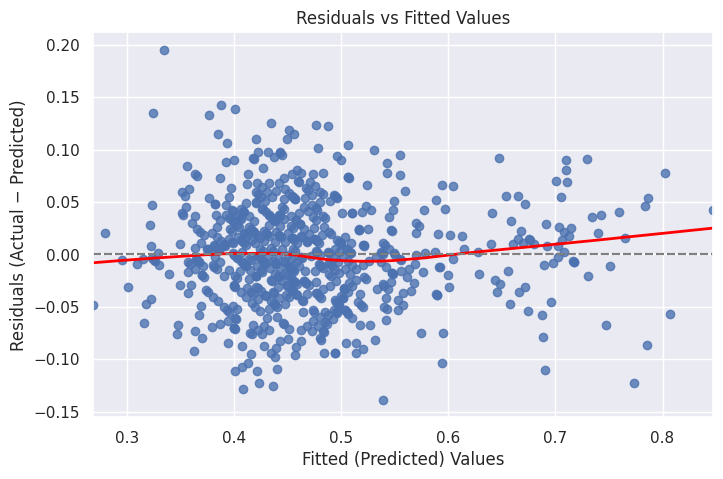

In [ ]:
# let's plot the fitted values vs residuals

plt.figure(figsize=(8,5))

#sns.residplot is a function from the Seaborn library that creates a residual plot.
sns.residplot(
    x="Predicted_Values",
    y="Actual_Values",
    data=df_pred,
    lowess=True, #enables lowess which fits the smooth line through the scatter points
    line_kws={"color": "red", "lw": 2}
)
plt.axhline(0, color="gray", linestyle="--")
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted (Predicted) Values")
plt.ylabel("Residuals (Actual − Predicted)")
plt.show()

**Observations**
* From the plot we can observe that blue points are distributed above and below the dashed grey 0-line, without a distinct systematic curve, and **no specific pattern observed**.
* The red smoothed line remains close to zero throughout the fitted value range. There is a minor upward tilt beyond ≈0.65M, but the difference is minimal (within ~0.02).
* Therefore, **no evidence of non-linearity found**.
* Residuals do not cluster in time-like bands or display any patterns; instead, points appear randomly scattered.
* The independence of residuals appears evident.
* **We see no pattern in the plot above. Hence, the assumptions of linearity and independence are satisfied.**

###**Test For Normality of Residuals**

* Normality test is done:
   * The error terms, or residuals, should follow a normal distribution.  If the error components are not normally distributed, the confidence interval for coefficient estimates may become overly large or narrow.  When a confidence interval becomes unstable, it makes it harder to estimate coefficients using least squares minimisation.  Non-normality indicates that a few unexpected data points must be thoroughly investigated in order to create a better model.

* Normality check steps:
   * The shape of the residuals histogram can provide a first understanding of normality.
   * It can also be verified using a Q-Q plot of residuals.  If the residuals have a normal distribution, they will result in a straight line plot, otherwise not.
   * The Shapiro-Wilk test is another method for determining normality.
     * Null hypothesis: The residuals are regularly distributed.
     * Alternative hypothesis: The residuals are not normally distributed.


* If assumption failed then we can apply transformations such as log, exponential, and arcsinh, etc., to our data.



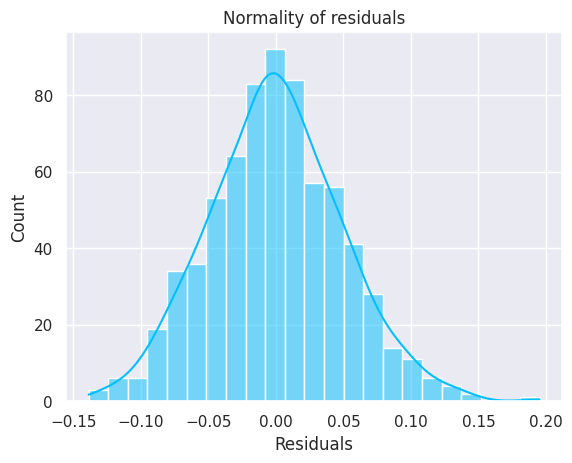

In [ ]:
sns.histplot(data=df_pred, x="Residuals", kde=True,color = "deepskyblue")
plt.title("Normality of residuals")
plt.show()

**Observations**
* The histogram of residuals does have a bell curve.
* Therefore, **normality of residuals assumptions is satisfied**.
------------------------------------------------------------------------------

**Let's check the Q-Q plot.**

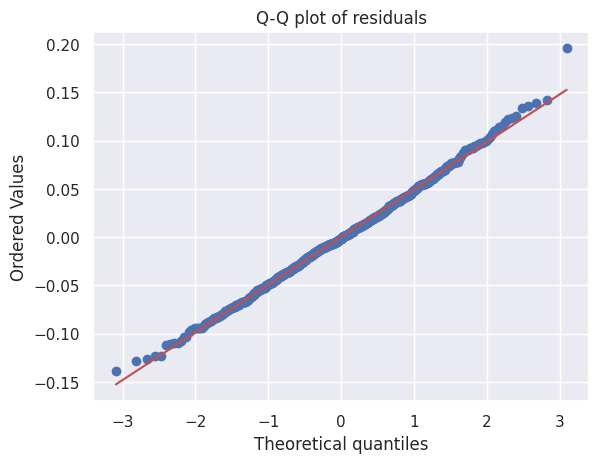

In [ ]:
import pylab
import scipy.stats as stats

stats.probplot(df_pred["Residuals"], dist="norm", plot=pylab)
plt.title("Q-Q plot of residuals")
pylab.show()


**Observations**
* We can clearly see from the plot that the blue points follow the red diagonal line quite closely over the centre range.
* This indicates that the residuals are approximately normally distributed.
* Even though slight deviation at the end (tails), suggesting there are a few points that slightly deviate from the red line at both extremes (left < -2.5 and right > +2.5).
* This is normal for real-world data and d**oes not violate the normality assumption.**



**Let's check the results of the Shapiro-Wilk test.**

* Null hypothesis (H₀): The residuals are normally distributed.

* Alternative hypothesis (H₁): The residuals are not normally distributed.

In [ ]:
stats.shapiro(df_pred["Residuals"])

ShapiroResult(statistic=np.float64(0.9974196775216243), pvalue=np.float64(0.34572330104601723))

**Observations:**
* Since **p-value (0.3457) > 0.05**, we fail to reject null hypothesis, the residuals are normal as per the Shapiro-Wilk test.
* **So, the normality assumption is satisfied.**

###**Test For Homoscedasticity**

**Homoscedascity:** If the variance of the residuals is symmetrically distributed throughout the regression line, the data is considered homoscedastic.

**Heteroscedascity:** If the variance of the residuals across the regression line is unequal, the data is considered heteroscedastic.

**Need for the test:**

* The presence of non-constant variance in the residuals causes heteroscedasticity.
* Non-constant variance occurs in the presence of outliers.

**checking for homoscedasticity:**

* The residual vs fitted values plot can be used to test for homoscedasticity.  Heteroscedasticity can result in non-symmetrical residual shapes, such as arrows.  The Goldfeld-Quandt test can also be utilised.  If the p-value exceeds 0.05, we can conclude that the residuals are homoscedastic.  Otherwise, they're heteroscedastic.
     * Null hypothesis: The residuals are homoscedastic.
     * Alternative hypothesis: Residuals exhibit heteroscedasticity

* If this assumption is not followed then heteroscedasticity can be reduced by incorporating more essential features or performing transformations.

In [ ]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(df_pred["Residuals"], x_train1)
lzip(name, test)

[('F statistic', np.float64(1.1814881410405407)),
 ('p-value', np.float64(0.06287983026238401))]

**Observations**

* Since p-value **(0.062) > 0.05**, fail to reject H₀, no evidence of heteroscedasticity.
* **We can say that the residuals are homoscedastic. So, this assumption is satisfied.**
------------------------------------------------------------------------------

**All the assumptions of linear regression model are satisfied.**

#**FINAL MODEL & PERFORMANCE EVALUATION**

Let's recreate the final model and print it's summary to gain insights.

In [ ]:
x_train_final = x_train1.copy()
x_test_final = x_test1.copy()

olsmodel_final = sm.OLS(y_train, x_train_final).fit()
print(olsmodel_final.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.786
Model:                            OLS   Adj. R-squared:                  0.783
Method:                 Least Squares   F-statistic:                     229.7
Date:                Wed, 09 Jul 2025   Prob (F-statistic):          8.48e-222
Time:                        10:03:26   Log-Likelihood:                 1115.3
No. Observations:                 700   AIC:                            -2207.
Df Residuals:                     688   BIC:                            -2152.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.6842    

## **Displaying model coefficients with column name**

In [ ]:
# Create a DataFrame of coefficients with column names

coef_df = pd.DataFrame({
    "Feature": x_train_final.columns,
    "Coefficient": olsmodel_final.params.values
})

# Display the DataFrame
coef_df



,Feature,Coefficient
0,const,-0.684187
1,visitors,0.129517
2,major_sports_event,-0.063322
3,views_trailer,0.221317
4,dayofweek_Monday,0.028619
5,dayofweek_Saturday,0.056312
6,dayofweek_Sunday,0.034750
7,dayofweek_Thursday,0.013534
8,dayofweek_Wednesday,0.044889
9,season_Spring,0.024770


## **Model Performance Check**

In [ ]:
# checking final model performance on train set (seen 70% data)
olsmodel_final_train_perf = evaluate_regression(
    olsmodel_final, x_train_final, y_train)


# checking final model performance on test set (seen 30% data)
olsmodel_final_test_perf = evaluate_regression(
    olsmodel_final, x_test_final, y_test)

print("Final Model Performance:\n")
final_perf_table = pd.concat([olsmodel_final_train_perf,
olsmodel_final_test_perf], axis=0)
final_perf_table.index = ["Train", "Test"]
print(final_perf_table)



Final Model Performance:

           RMSE       MAE  R-squared  Adj. R-squared  MAPE (%)
Train  0.049184  0.038688   0.785965        0.782227  8.603114
Test   0.050850  0.040957   0.764165        0.754304  9.114764


**Observations**
* The model is able to explain ~76% of the variation in the data

* The train and test RMSE and MAE are low and similar, showing that the model generalises well with slight overfitting, which is acceptable and expected in real-world scenarios.

* The MAPE on the test set suggests we can predict within 9.11% of the content views.

* Hence, we can conclude the model *olsmodel_final* is good for prediction as well as inference purposes

**Let's compare the initial and final models.**

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [olsmodel_train_perf.T, olsmodel_final_train_perf.T],
    axis=1,
)

models_train_comp_df.columns = [
    "Linear Regression (original)",
    "Linear Regression (final)",
]

print("Training performance comparison:\n")
print(models_train_comp_df)



# test performance comparison

models_test_comp_df = pd.concat(
    [olsmodel_test_perf.T, olsmodel_final_test_perf.T],
    axis=1,
)

models_test_comp_df.columns = [
    "Linear Regression (original)",
    "Linear Regression (final)",
]

print("\n\nTest performance comparison:\n")
print(models_test_comp_df)


Training performance comparison:

                Linear Regression (original)  Linear Regression (final)
RMSE                                0.048844                   0.049184
MAE                                 0.038426                   0.038688
R-squared                           0.788913                   0.785965
Adj. R-squared                      0.782374                   0.782227
MAPE (%)                            8.549048                   8.603114


Test performance comparison:

                Linear Regression (original)  Linear Regression (final)
RMSE                                0.050487                   0.050850
MAE                                 0.040592                   0.040957
R-squared                           0.767519                   0.764165
Adj. R-squared                      0.749958                   0.754304
MAPE (%)                            9.009553                   9.114764


**Final Model Overall Observations & Interpretations**


**R-squared and Adjusted  R-squared:**
 * ***R-squared Train***
   * Original: 0.7889.
   * Final: 0.7860.

 * ***R-squared Test***
   * Original: 0.7675.
   * Final: 0.7641.

* After removing high p-value predictors, the model's R² shows a little decline (≈0.002-0.003), but it still explains around **76% of the variation in test data**.


**Adjusted  R-squared:**
* ***Adjusted R-squared Train***
  * Original value: 0.7824.
  * Final value: 0.7822.

* ***Adjusted R-squared Test***
  * Original value: 0.7500
  * Final value: 0.7543 (a slight improvement)

* The final model's Adjusted R² on test data improved marginally, indicating that even though it has fewer variables, it still generalises well.

**Model coefficients (significance):**
  * **All predictors now have p-values < 0.05**, indicating that all variables in the model are statistically significant.
  * Key variables with the biggest influence (high t-values) is **views_trailer (t ≈ 42) and it is the primary driver of viewership.**
  * Other key Predictors: visitors, major_sports_event, dayofweek_Wednesday, and season_Summer all contribute significantly.


**Error Metrics:**

**1. Mean Absolute Error (MAE)**

* ***Train MAE***
   * Original MAE: 0.0384.
   * Final MAE value: 0.0387.
   * The difference is minimal (0.0003), indicating similar average error on the observed data.

* ***Test MAE***
  * Originally MAE: 0.0406
  * Final MAE value: 0.0410.
  * Again, a little rise (0.0004), but still within acceptable limits.

* The average error in predictions increased slightly but remained very low, approximately 40,000 views off, which is acceptable for business purposes.


**2. Root Mean Squared Error (RMSE)**

* ***Train RMSE***
  * Original: 0.0488.
  * Final value: 0.0492

* ***Test RMSE***
  * Original: 0.0505
  * Final: 0.0508

* RMSE is also extremely steady.  Although the final model includes fewer features, the error is still around 0.05M, showing good predictive accuracy.

**3. Mean Absolute Percentage Error (MAPE)**

* ***MAPE Train***
  * Original: 8.55%.
  * Final: 8.60%

* ***MAPE Test***
  * Original: 9.01%.
  * Final: 9.11%

* The model predicts ±0.045M views for most content, with only a minor increase in average percentage error (around 10%), still within the acceptable range.

**Conclusion**

* The final linear regression model exhibits a great fit and consistent predictive power:

 * Train R² = 0.786, Test R² = 0.764, with a slight decline (~2.2%).
 * Since, achieved an R-squared of 0.764 on the test set, explaining 76% of the variance in first-day content viewership
 * MAPE is 8.6% (Train) vs. 9.1% (Test), while RMSE/MAE demonstrate negligible variability between training and testing sets.
 * These tiny and acceptable variances imply that the model generalises well, which means it performs consistently on unseen data.
 * There is no evidence of overfitting (where the model memorises the training data) or underfitting (where the model fails to learn the patterns).
* Thus, we conclude that the **final model** is statistically solid, interpretable, and commercially viable for identifying important drivers of first-day content viewership on the OTT platform.
------------------------------------------------------------------------------

##**Predictions on Test Data**

In [ ]:
# predict on unseen (test) data
y_pred_test = olsmodel_final.predict(x_test_final)

# combine actual and predicted values in one DataFrame
df_pred_test = pd.DataFrame({
    "Actual":    y_test,           # the true target values
    "Predicted": y_pred_test       # model forecasts
})

# look at 10 random rows (reproducible)
df_pred_test.sample(n=10, random_state=1)




,Actual,Predicted
983,0.43,0.444878
194,0.51,0.518432
314,0.48,0.437527
429,0.41,0.492618
267,0.41,0.484167
746,0.68,0.644531
186,0.62,0.619178
964,0.48,0.502187
676,0.42,0.491791
320,0.58,0.591065


In [ ]:
#checking Absolute error
df_pred_test["Absolute_Error"] = abs(df_pred_test["Actual"] - df_pred_test["Predicted"])
#average Absolute error
df_pred_test["Absolute_Error"].mean()


np.float64(0.04095661080298247)

**Observations**
* The model's average absolute error on the test set is around 0.041 million views, implying that forecasts differ from actual first-day views by around 41,000 views on average.
* This inaccuracy is rather small, especially given that the target values (views_content) range around between 0.30 and 0.80 million.
* Given that the Mean Absolute Percentage Error (MAPE) was also approximately 9%, this level of error is reasonable for business decision-making and indicates that the model makes solid predictions on unseen data.

#**ACTIONABLE INSIGHTS**

**Model Performance**
* The final linear regression model is highly predictive, with a **test R-squared of 0.764 (train = 0.786)**, explaining **76.4%** of the variance in first-day content viewership.  
* The model exhibits strong generalisation with minimal overfitting (only 2.2% drop from training to test) and retains commercial viability with a **MAPE of 9.11%**, suggesting predictions tend to be within ±9% of actual viewership.

**Significance of Predictors**

***Primary Drivers***

***1. views_trailer(Coefficient: 0.221, 95% CI: [0.211, 0.232])***

* The **most significant predictor** with the highest statistical influence (**p < 0.001, t = 42.081**).
* Since, the coefficient (**0.221**) is positive, it has positive linear relationship with the target variable.
* There is a **0.221 million** increase in content views for every unit increase in trailer views.
* The true effect is between **0.211 and 0.232 million views**, as per the confidence interval.
* Therefore, trailer views is the best indicator of first-day viewership success.

***2. visitors (Coefficient: 0.130; 95% confidence interval: [0.114, 0.145])***
* The second most significant predictor (**t = 16.029, p < 0.001.**).
* The coefficient (**0.130**) is positive, indicating a positive linear relationship with the target variable.
* Each unit increase in visitors increases content views by **0.130 million views**.
* The confidence interval confirms a positive effect between **0.114 and 0.145 million views**.
* This shows a direct  relationship between platform traffic and content success.

***3. major_sports_event (Coefficient: -0.063; 95% CI: [-0.071, -0.056])***
* A significant negative impact on content viewership (**t = -16.202, p < 0.001**).
* Since, the coefficient (**-0.063**) is negative, it suggests a negative linear relationship with the target variable.
* Sports events decrease content views by **0.063 million views** with high confidence.
* The confidence interval reveals a consistent negative effect of -0.071 to -0.056 million views.
* This is a significant drop, suggesting that sports events considerably reduce viewership.


***Temporal Patterns***

***1. Day of Week Effects:***

* Saturday (**coef: 0.056, 95% CI: [0.042, 0.070]**) shows the strongest positive impact on content views (**t = 7.885, p < 0.001**), indication weekend drive higher viewership. Thus, launching content on Saturdays will be beneficial, as it is likely to increase viewership.

* Wednesday (**coef: 0.045, 95% CI: [0.036, 0.054]**) displays second highest weekday influence, with consistently strong effect (**t = 10.095, p < 0.001**).
It shows the strongest statistical significance, suggesting a highly reliable effect on boosting views mid-week.

* Sunday (**coef: 0.035, 95% CI: [0.019, 0.050]**) offers a moderate weekend advantage in views(**t = 4.472, p < 0.001**). It is a favourable day for content drops.

* Monday (**coef: 0.029, 95% CI: [0.005, 0.052]**) has smaller but still statistically significant increase in views(**t = 2.420, p = 0.016**). This indicates Mondays can support light content launches.

* Thursday (**coef: 0.014, 95% CI: [0.000, 0.027]**) has a lowest positive impact, but remains statistically significant (**t = 2.006, p = 0.045**). The day is suitable for experimental or niche content releases.


***2. Seasonal Variations:***

***Summer***
* Summer shows the **highest positive effect** on first-day content views.
* Coefficient: **0.045, 95% CI: [0.034, 0.055], t = 8.310, p < 0.001**
* Thus,Summer brings the strongest seasonal boost in viewership.

***Winter***

* Winter has a **moderate yet significant effect**.
* Coefficient: **0.028, 95% CI: [0.018, 0.039], t = 5.339, p < 0.001**
* Winter contributes a meaningful uplift to content views, second only to summer.

***Spring***
* Spring provides the **smallest but still significant impact**.
* Coefficient: **0.025, 95% CI: [0.014, 0.035], t = 4.636, p < 0.001**
* Spring has a lesser influence, yet its effect is statistically reliable.


**Main Inferences**

* All predictors in the final model are statistically significant (p < 0.05) and have narrow confidence intervals that do not include zero, enhancing the reliability of predictor estimates.  
* The model's commercial relevance for business decision-making is validated by its consistent performance across training and testing datasets **(RMSE: 0.0508, MAE: 0.0410)**.


**Model Limitations**
* In order to improve prediction accuracy, future research could investigate interaction effects, such as how trailer views vary across seasons or sporting events, which are not taken into consideration by the current model.


#**BUSINESS RECOMMENDATIONS**

**1. Marketing Strategy**

***Prioritise Trailer Investment:***
* Channel digital ad budget is based on trailer-to-view ratio criteria.
 Give top priority to high-ROI trailer forms, like short-form and platform-native trailers.
* Set trailer view targets as the primary indicators of content performance.

***Improve Web Traffic Generation:***
* Utilise internal analytics to evaluate landing pages for visitor-to-view conversion.
* Channel marketing spends on audience building and conversion optimisation.
 Develop a content marketing plan to increase organic traffic.

**2. Scheduling Optimisation**

***Strategic Release Timing:***
* Schedule premium content releases on Wednesdays and Saturdays to maximise impact.
* Use Sunday and Monday for secondary content launches.
* Avoid significant releases on baseline days (Tuesday and Friday).

***Seasonal Content Planning:***
* Launch significant campaigns over the summer for maximum seasonal increase.
* Plan secondary releases throughout the winter months.
* Use spring for audience growth and content preparation.

**3. Competitive Strategy**

***Mitigating Sports Events:***
* Create an automated sports event calendar to prevent scheduling conflicts.
* Create a counter-programming approach for unavoidable competitive instances.
* Implement content release blackout periods during major sporting events.

**4. Performance Monitoring**

***Model-Based Decision Making:***
* Implement real-time monitoring of all crucial predictors.
* Use the model's 76.4% explanatory power to predict content performance.
* Set up automated warnings for performance deviations from forecast values.

**5. Estimated Business Impact**

* **Immediate impact (3-6 months):** Improved accuracy in estimating first-day viewing by 15-20% through data-driven scheduling and trailer optimisation.

* **Strategic shift (6-12 months):** Season-aware and trailer-first strategy alignment leads to a ~25-30% boost in platform-wide engagement.

* **Long-term transformation (over 12 months):** Implementation of predictive analytics for release planning and marketing ROI optimisation.

* The model's statistical robustness **(R² = 0.764, MAPE = 9.11%)** indicates that these recommendations will lead to **significant improvements in OTT platform content performance**.